# 1961-01-01 ~ 2026-09-13 서울과 추풍령, 대구에 대한 생활 기후 분석 -불쾌지수를 중심으로

> **자료 출처** — 본 노트북은 기상청에서 개방한 「종관기상관측(ASOS) 일자료」(서울 108, 대구 143, 추풍령 135)와
> 「관측지점정보」를 이용하였으며, codysseus42가 결측·이상치 처리 및 지표 계산을 거쳐 재가공하였습니다.
> 원자료는 기상자료개방포털(data.kma.go.kr)에서 무료로 내려받을 수 있습니다.

## 작업 환경

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import platform
from IPython.display import display
from matplotlib.ticker import MultipleLocator

python_version = sys.version_info
print(f"python version: {python_version}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {plt.matplotlib.__version__ }")

python version: sys.version_info(major=3, minor=14, micro=7, releaselevel='final', serial=0)
pandas version: 3.0.6
matplotlib version: 3.11.2


## 데이터 로딩

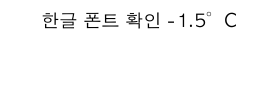

====================== loading ======================
<class 'pandas.DataFrame'>
DatetimeIndex: 71979 entries, 1961-01-01 to 2026-09-13
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   stn          71979 non-null  int64  
 1   stn_name     71979 non-null  str    
 2   tavg         71979 non-null  float64
 3   tmin         71979 non-null  float64
 4   tmax         71979 non-null  float64
 5   rh           71979 non-null  float64
 6   rh_min       71979 non-null  float64
 7   dew          71979 non-null  float64
 8   vp           71979 non-null  float64
 9   precip       27113 non-null  float64
 10  sunshine     71711 non-null  float64
 11  wind         71964 non-null  float64
 12  tmax_time    71975 non-null  float64
 13  rh_min_time  70614 non-null  float64
 14  station      71979 non-null  str    
 15  di           71979 non-null  float64
 16  di_min       71979 non-null  float64
 17  di_day       71979 non-null 

,stn,stn_name,tavg,tmin,tmax,rh,rh_min,dew,vp,precip,sunshine,wind,tmax_time,rh_min_time,station,di,di_min,di_day
date,,,,,,,,,,,,,,,,,,
1961-01-01,143,대구,-6.3,-10.1,-0.8,46.3,27.0,-16.5,1.7,NaN,8.3,3.7,1440.0,NaN,대구,31.688369,26.868563,41.57716
1961-01-02,143,대구,-3.7,-10.3,4.1,61.5,41.0,-10.5,2.8,NaN,8.2,1.2,1440.0,NaN,대구,32.255755,22.891345,45.42219
1961-01-03,143,대구,-2.8,-6.4,0.6,88.8,61.0,-4.4,4.5,5.4,0.0,0.9,2400.0,NaN,대구,28.872064,22.791232,38.42534
1961-01-04,143,대구,-4.5,-10.8,0.9,50.8,36.0,-13.4,2.3,NaN,8.4,3.8,5.0,NaN,대구,33.127460,24.856064,42.20176
1961-01-05,143,대구,-7.1,-13.3,-1.3,46.8,29.0,-17.0,1.7,NaN,5.4,3.5,1400.0,NaN,대구,30.567028,22.672444,40.72677


*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

plt.rcParams["font.family"] = {"Darwin": "AppleGothic",
                               "Windows": "Malgun Gothic"}.get(platform.system(), "NanumGothic")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
SOURCE = "자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공"


plt.figure(figsize=(3, 0.6)); plt.title("한글 폰트 확인 -1.5°C"); plt.axis("off"); plt.show()

#데이터 구조
print("====================== loading ======================")
df = pd.read_csv("data/processed/asos_clean.csv",index_col="date",parse_dates=True)

def discomfort_index(t, rh):
    """불쾌지수 (Thom, 1959). 일 단위로 계산한다."""
    return 0.81 * t + 0.01 * rh * (0.99 * t - 14.3) + 46.3

def shift_rh(cur, ref):
    """습도를 기준 기간 수준으로 옮긴다: 모든 날에서 (현재 평균 − 기준 평균)을 똑같이 뺀다."""
    return (cur - (cur.mean() - ref.mean())).clip(0, 100)
def decompose(d, B, t="tmax", h="rh_min", now_dec=2020):
    """2020년대를 기준 시기 B와 비교해 불쾌지수 변화를 기온 몫과 습도 몫으로 나눈다."""
    p, n = d[d.decade == B], d[d.decade == now_dec]
    a = discomfort_index(p[t], p[h])                            # 기준 시기 실제
    b = discomfort_index(n[t], n[h])                            # 2020년대 실제
    c = discomfort_index(n[t], shift_rh(n[h], p[h]))            # 2020년대, 습도만 기준 시기 수준
    return {"습도 변화(%p)": n[h].mean() - p[h].mean(),
            "기온 변화(°C)": n[t].mean() - p[t].mean(),
            "불쾌지수 변화": b.mean() - a.mean(),
            "습도 몫": b.mean() - c.mean(),
            "습도 비중(%)": (b.mean() - c.mean()) / (b.mean() - a.mean()) * 100,
            "80 이상 비율 변화(%p)": ((b >= 80).mean() - (a >= 80).mean()) * 100,
            "80 이상 습도 몫(%p)": ((b >= 80).mean() - (c >= 80).mean()) * 100,
            "80 이상 습도 비중(%)": ((b >= 80).mean() - (c >= 80).mean()) / ((b >= 80).mean() - (a >= 80).mean()) * 100}

df["di"] = discomfort_index(df.tavg, df.rh)
df["di_min"] = discomfort_index(df.tmin, df.rh)
df["di_day"] = discomfort_index(df.tmax, df.rh_min)   # 낮: 최고기온 + 최소습도

df.info()
print(f"컬럼 {len(df.columns)}개")
print(f"행 {len(df)}개")
print("정제 자료 첫 5행 — 3지점 통합")
display(df.head())
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")




## Q1 습도의 증가는 기온의 증가와 비례하지만 다를 수 있다. 서울의 습도 변화는 불쾌지수에 얼마나 기여했을까? - 서울의 온도, 습도, 불쾌지수

최근(2020년대) 여름은 습도 때문에 더 힘들다는 주장을 인터넷에서 자주 접한다.
이 절에서는 불쾌지수로 이 주장을 확인한다.

**진행 순서**
1. 여름 연평균 추세 — 기온, 상대습도, 불쾌지수가 각각 어떻게 변했는가
2. 가설 1 — 높은 불쾌감을 주는 날(불쾌지수 80 이상)의 증가에 습도가 기여했는가 (1990년대 기준)
3. 가설 2 — 기억 가설: 유난히 건조했던 2010년대와 비교하고 있는 것은 아닐까 (2010년대 기준)
4. 기준 시기별 비교와 소결

**요약**
- 66년 전체로 보면 불쾌지수의 상승은 기온이 이끌었고, 상대습도는 오히려 낮아졌다.
- 1990년대 기준으로는 습도의 기여가 거의 없고, 2010년대 기준으로는 낮 불쾌지수 상승의 76%, 80 이상 일수 증가의 58%가 습도 몫이다.
- 불쾌지수가 실제 불쾌감을 반영하는지, 사람들이 실제로 2010년대와 비교하는지는 이 데이터로 확인할 수 없다.
  자세한 서술과 한계는 REPORT.md의 Q1을 참고한다.

### 서울의 전체 기간 일별 관측

1961~2026년의 일별 평균·최고·최저기온, 상대습도, 불쾌지수를 그대로 나열하면
매년 반복되는 계절 변화(여름과 겨울의 기온 차이 약 30°C)가 화면을 채워,
66년간의 변화(여름 평균기온 약 2°C 상승)가 눈에 띄지 않는다.

따라서 이후 분석은 매년 여름(6~8월)만 모아 평균을 낸 **여름 연평균**을 기본 단위로 한다.
여름만 보면 계절 변화가 사라지고 해마다의 차이만 남는다.

굵은 선은 365일 이동평균이다.

====================== 서울 기후 데이터 ======================
기간: 1961-01-01 00:00:00 ~ 2026-09-13 00:00:00
<class 'pandas.DataFrame'>
DatetimeIndex: 23994 entries, 1961-01-01 to 2026-09-13
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   stn          23994 non-null  int64  
 1   stn_name     23994 non-null  str    
 2   tavg         23994 non-null  float64
 3   tmin         23994 non-null  float64
 4   tmax         23994 non-null  float64
 5   rh           23994 non-null  float64
 6   rh_min       23994 non-null  float64
 7   dew          23994 non-null  float64
 8   vp           23994 non-null  float64
 9   precip       9566 non-null   float64
 10  sunshine     23873 non-null  float64
 11  wind         23985 non-null  float64
 12  tmax_time    23994 non-null  float64
 13  rh_min_time  23539 non-null  float64
 14  station      23994 non-null  str    
 15  di           23994 non-null  float64
 16  di_min       23994 non

,stn,stn_name,tavg,tmin,tmax,rh,rh_min,dew,vp,precip,sunshine,wind,tmax_time,rh_min_time,station,di,di_min,di_day
date,,,,,,,,,,,,,,,,,,
1961-01-01,108,서울,-9.8,-15.0,-4.9,73.8,42.0,-14.0,2.1,NaN,2.7,0.8,1331.0,NaN,서울,20.648524,12.637300,34.28758
1961-01-02,108,서울,-6.2,-12.3,0.2,72.3,34.0,-11.1,2.6,NaN,4.9,1.4,1353.0,NaN,서울,26.501326,17.194129,41.66732
1961-01-03,108,서울,-1.1,-4.7,0.3,77.0,62.0,-4.9,4.4,3.7,0.0,2.6,1518.0,NaN,서울,33.559470,27.899190,37.86114
1961-01-04,108,서울,-9.5,-13.7,-4.7,46.0,32.0,-19.1,1.4,NaN,8.4,2.9,0.0,NaN,서울,27.700700,22.386020,36.42804
1961-01-05,108,서울,-10.8,-16.5,-6.2,54.3,25.0,-19.3,1.4,NaN,6.2,0.9,1250.0,NaN,서울,23.981344,16.300195,36.16850


*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*


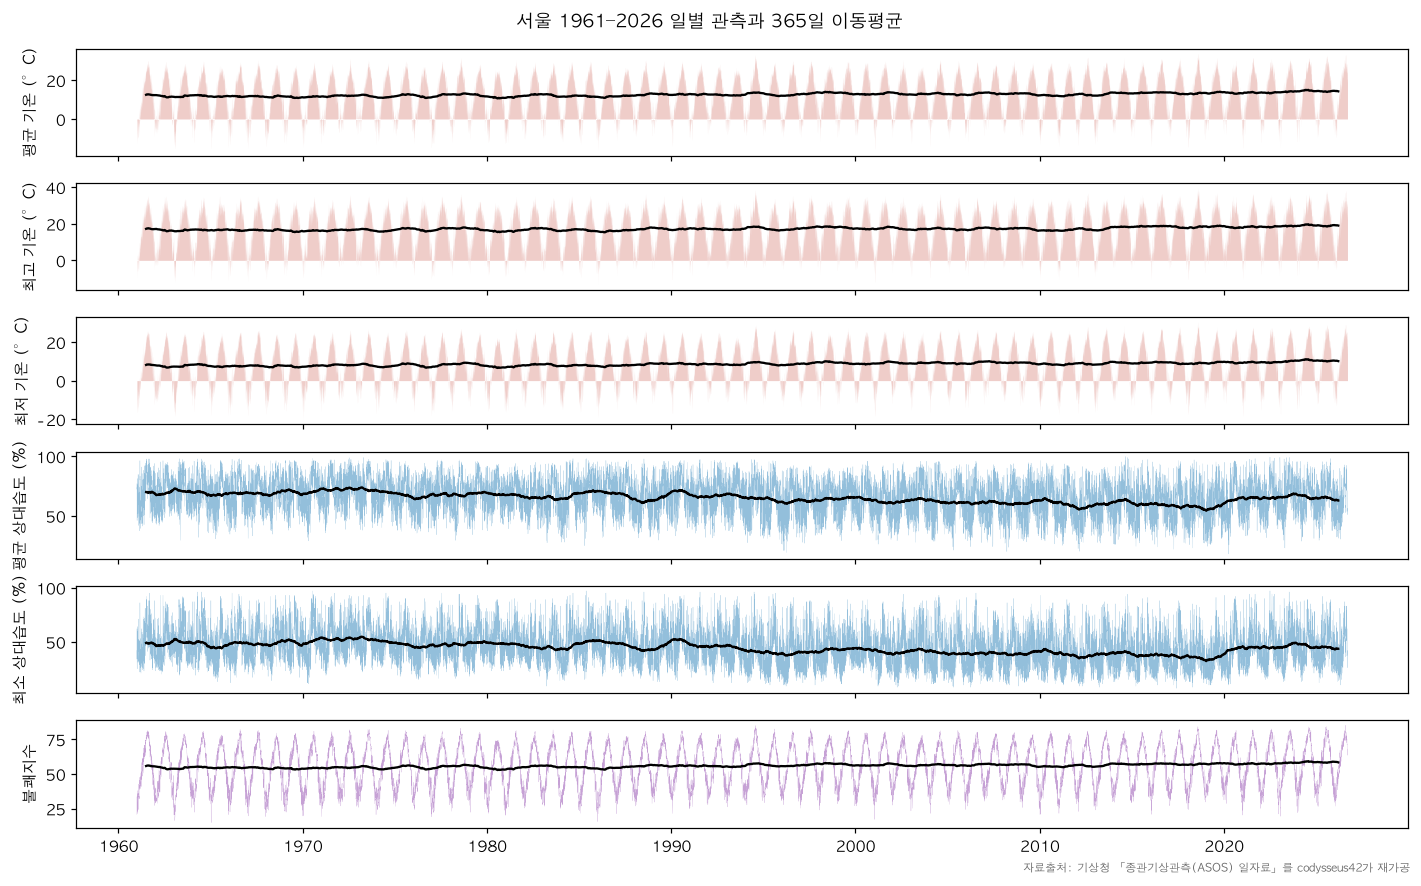

In [3]:
df_seoul = df[df.stn_name == "서울"].copy()

print("====================== 서울 기후 데이터 ======================")
print(f"기간: {df_seoul.index.min()} ~ {df_seoul.index.max()}")
df_seoul.info()
print(f"컬럼 {len(df_seoul.columns)}개")
print(f"행 {len(df_seoul)}개")
print(list(df_seoul.columns))
print("서울 자료 첫 5행")
display(df_seoul.head())
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")

fig, axes = plt.subplots(6, 1, figsize=(13, 8), sharex=True)

axes[0].fill_between(df_seoul.index, df_seoul.tavg,
                     alpha=0.25, lw=0, color="#c0392b")
axes[0].plot(df_seoul.index, df_seoul.tavg.rolling(365, center=True).mean(),
             lw=1.5, color="k")
axes[0].set_ylabel("평균 기온 (°C)")

axes[1].fill_between(df_seoul.index, df_seoul.tmax,
                     alpha=0.25, lw=0, color="#c0392b")
axes[1].plot(df_seoul.index, df_seoul.tmax.rolling(365, center=True).mean(),
             lw=1.5, color="k")
axes[1].set_ylabel("최고 기온 (°C)")

axes[2].fill_between(df_seoul.index, df_seoul.tmin,
                     alpha=0.25, lw=0, color="#c0392b")
axes[2].plot(df_seoul.index, df_seoul.tmin.rolling(365, center=True).mean(),
             lw=1.5, color="k")
axes[2].set_ylabel("최저 기온 (°C)")

axes[3].plot(df_seoul.index, df_seoul.rh, lw=0.15, color="#2980b9", alpha=0.5)
axes[3].plot(df_seoul.index, df_seoul.rh.rolling(365, center=True).mean(),
             lw=1.5, color="k")
axes[3].set_ylabel("평균 상대습도 (%)")

axes[4].plot(df_seoul.index, df_seoul.rh_min, lw=0.15, color="#2980b9", alpha=0.5)
axes[4].plot(df_seoul.index, df_seoul.rh_min.rolling(365, center=True).mean(),
             lw=1.5, color="k")
axes[4].set_ylabel("최소 상대습도 (%)")

axes[5].plot(df_seoul.index, df_seoul.di, lw=0.15, color="#8e44ad", alpha=0.5)
axes[5].plot(df_seoul.index, df_seoul.di.rolling(365, center=True).mean(),
             lw=1.5, color="k")
axes[5].set_ylabel("불쾌지수")

fig.suptitle("서울 1961–2026 일별 관측과 365일 이동평균", fontsize=12)
fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
plt.tight_layout(); 
plt.savefig("imagedata/fig_all.png", bbox_inches="tight", dpi=150)
plt.show()

### 여름 연평균 시각화

기온과 불쾌지수는 상승하고 상대습도는 하강하는 추세를 확인할 수 있다(추세선: 최소제곱 직선).
- 관찰: 여름 평균기온 +0.36°C/10년, 일평균 불쾌지수 +0.39/10년, 평균 상대습도 −1.52%p/10년
- 해석: 불쾌지수 산출에서 고려되는 습도 요소는 상대습도뿐인데, 서울의 여름 상대습도는 전체 기간에서 오르지 않았다.
  따라서 불쾌지수의 상승은 습도가 아니라 기온의 상승에서 온 것으로 보인다.

최저기온 기준 불쾌지수는 상승 추세가 가장 크다(+0.47/10년).
다만 밤의 상대습도는 일평균보다 높으므로, 일평균 상대습도를 짝지은 이 지표는 밤의 불쾌지수를 다소 낮게 추정한다.
최소 상대습도처럼 최저기온 시각에 맞는 습도 자료가 없어 정확도가 가장 떨어지므로, 이후 분석에서는 제외한다.

마지막 그림은 최소 상대습도가 관측된 시각과 최고기온이 관측된 시각의 차이 분포다(시각 기록이 없는 1961년 여름 제외).
- 관찰: 차이의 중앙값은 38분이고, 78%가 2시간 이내다.
- 해석: 두 값은 대체로 같은 시간대(오후)에 나타나므로, 최고기온과 최소 상대습도를 짝지어 낮 불쾌지수로 쓸 수 있다.

====================== 서울 여름철 기후 데이터 ======================
<class 'pandas.DataFrame'>
DatetimeIndex: 6071 entries, 1961-06-01 to 2026-08-31
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   stn          6071 non-null   int64  
 1   stn_name     6071 non-null   str    
 2   tavg         6071 non-null   float64
 3   tmin         6071 non-null   float64
 4   tmax         6071 non-null   float64
 5   rh           6071 non-null   float64
 6   rh_min       6071 non-null   float64
 7   dew          6071 non-null   float64
 8   vp           6071 non-null   float64
 9   precip       3358 non-null   float64
 10  sunshine     6024 non-null   float64
 11  wind         6070 non-null   float64
 12  tmax_time    6071 non-null   float64
 13  rh_min_time  5979 non-null   float64
 14  station      6071 non-null   str    
 15  di           6071 non-null   float64
 16  di_min       6071 non-null   float64
 17  di_day       6071 non-n

,stn,stn_name,tavg,tmin,tmax,rh,rh_min,dew,vp,precip,sunshine,wind,tmax_time,rh_min_time,station,di,di_min,di_day
date,,,,,,,,,,,,,,,,,,
1961-06-01,108,서울,19.9,14.3,26.2,74.5,52.0,15.0,17.0,NaN,10.0,1.7,1446.0,NaN,서울,66.442745,57.776465,73.57376
1961-06-02,108,서울,21.6,15.1,29.0,68.3,30.0,14.6,16.5,NaN,9.4,1.7,1542.0,NaN,서울,68.634372,58.974267,74.11300
1961-06-03,108,서울,23.9,17.0,29.0,54.8,33.0,13.7,15.6,0.9,11.6,1.7,1517.0,NaN,서울,70.788828,61.456440,74.54530
1961-06-04,108,서울,17.3,14.8,20.8,85.8,69.0,14.8,16.7,12.7,3.7,3.2,1424.0,NaN,서울,62.738566,58.590016,67.48948
1961-06-05,108,서울,20.0,14.2,25.4,68.0,38.0,13.2,15.1,NaN,9.3,2.6,1433.0,NaN,서울,66.240000,57.637440,70.99548


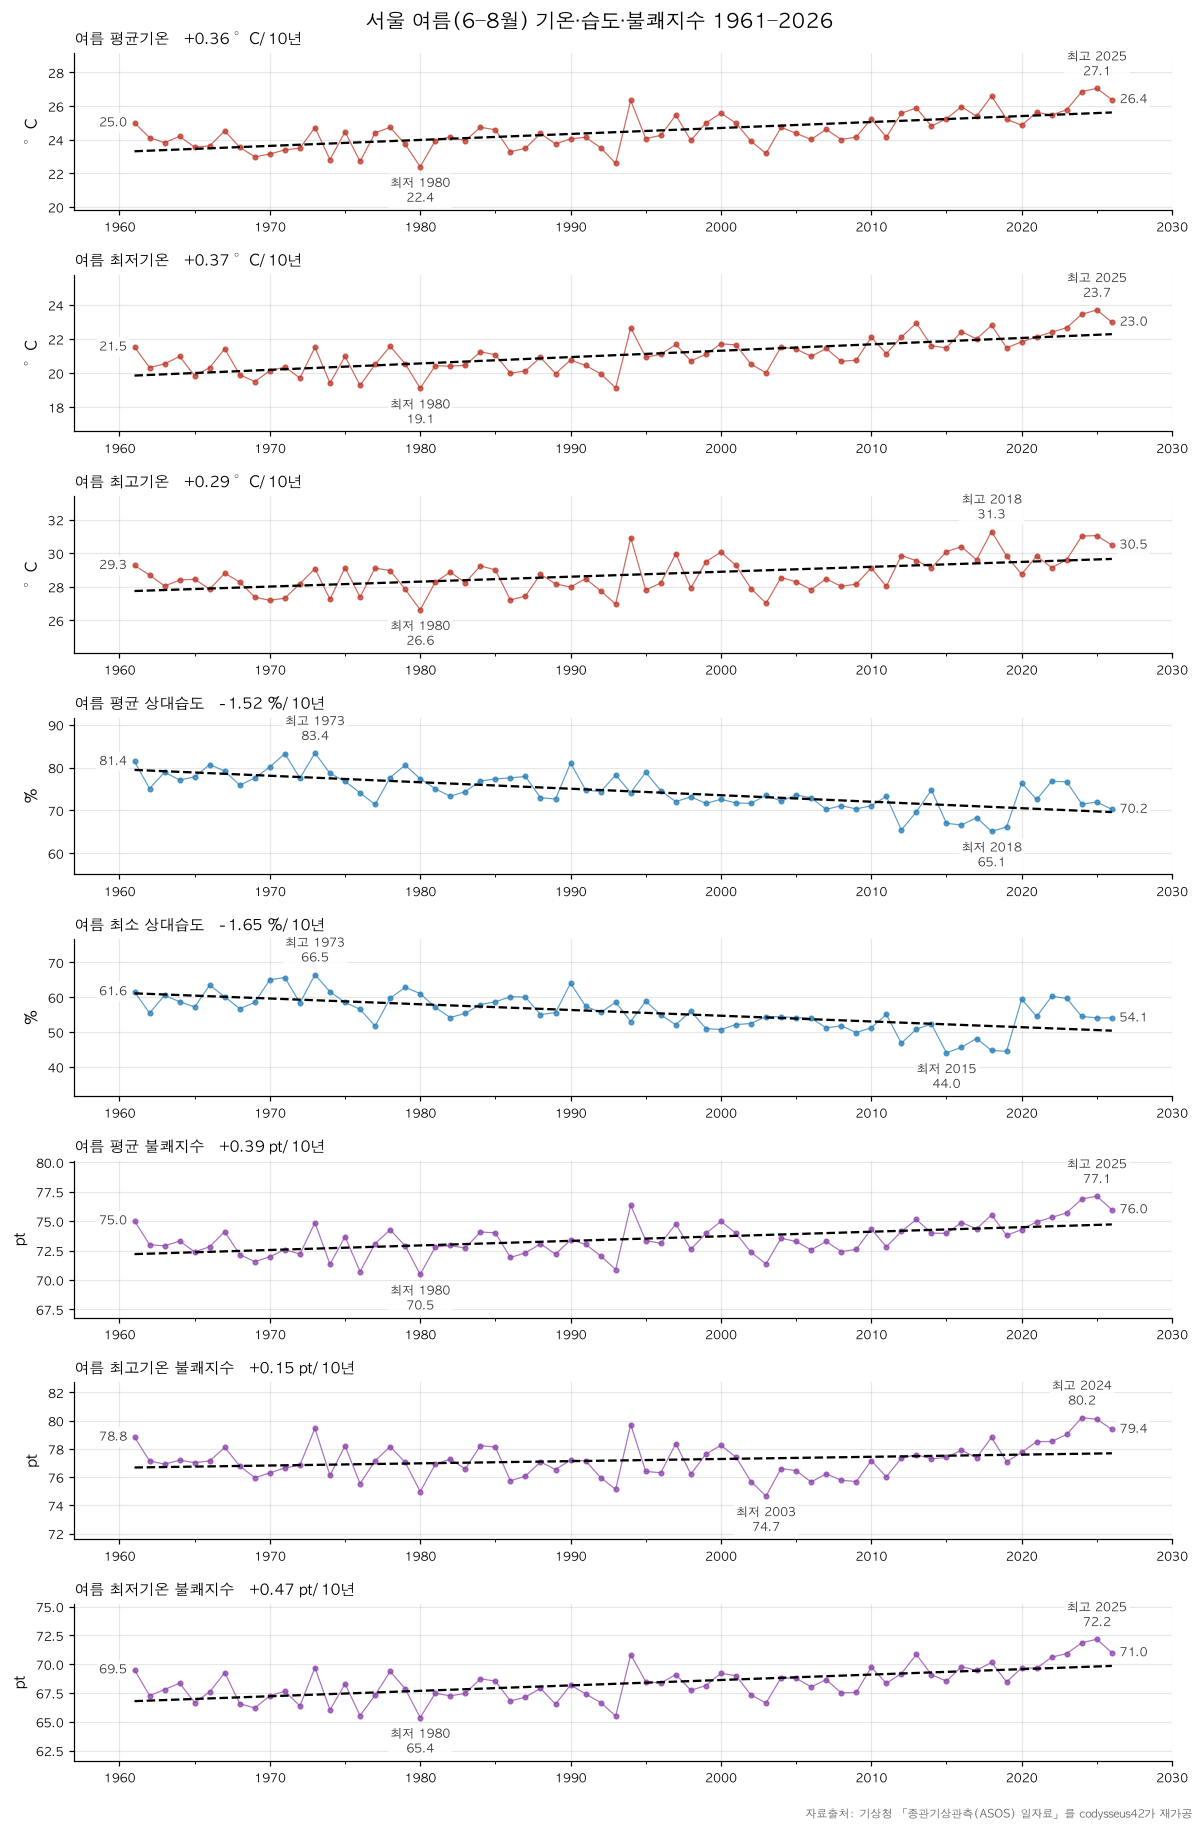

여름 5,979일 (시각 기록이 없는 날 92일 제외)
시각 차이 중앙값 38분 · 1시간 이내 60% · 2시간 이내 78% · 3시간 이내 86%
최고기온 시각 중앙값 1459 · 최소습도 시각 중앙값 1438


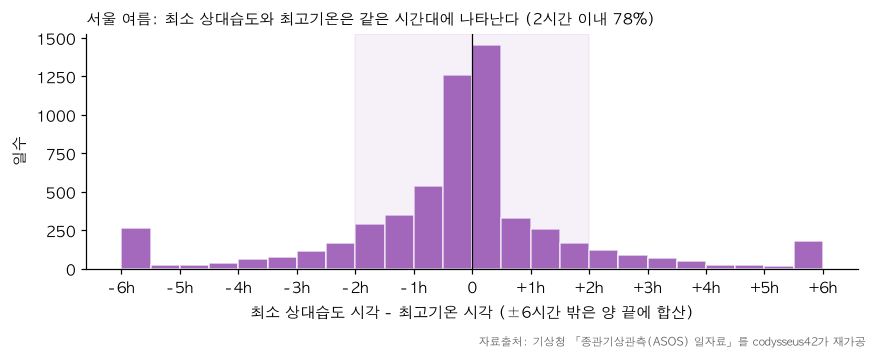

In [4]:


SUMMER = [6, 7, 8]
s = df_seoul[df_seoul.index.month.isin(SUMMER)].copy()
print("====================== 서울 여름철 기후 데이터 ======================")

s.info()
print(f"컬럼 {len(s.columns)}개")
print(f"행 {len(s)}개")
print("서울 여름(6~8월) 자료 첫 5행")
display(s.head())

yr = s.groupby(s.index.year)[["tavg", "tmin", "tmax", "rh","rh_min" ,"dew", "di", "di_day", "di_min"]].mean()
yr = yr.loc[1961:2026]

panels = [
    ("tavg",   "여름 평균기온",          "°C", "#c0392b"),
    ("tmin",   "여름 최저기온",          "°C", "#c0392b"),
    ("tmax",   "여름 최고기온",          "°C", "#c0392b"),
    ("rh",     "여름 평균 상대습도",     "%",  "#2980b9"),
    ("rh_min",     "여름 최소 상대습도",     "%",  "#2980b9"),
    ("di",     "여름 평균 불쾌지수",     "pt", "#8e44ad"),
    ("di_day", "여름 최고기온 불쾌지수", "pt", "#8e44ad"),
    ("di_min", "여름 최저기온 불쾌지수", "pt", "#8e44ad"),
]

LABEL = dict(fontsize=8, color="#333", ha="center", textcoords="offset points",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))

fig, axes = plt.subplots(len(panels), 1, figsize=(11, 2.1 * len(panels)), sharex=True)
for ax, (col, title, unit, c) in zip(axes, panels):
    y = yr[col]
    ax.plot(y.index, y, "o-", ms=3, lw=0.8, color=c, alpha=0.75)
    k, b = np.polyfit(y.index, y, 1)
    ax.plot(y.index, k * y.index + b, "k--", lw=1.5)

    # 위아래 여백: 최고·최저 라벨이 들어갈 자리
    lo, hi = y.min(), y.max()
    span = hi - lo
    ax.set_ylim(lo - span * 0.55, hi + span * 0.45)

    # 최고값은 점 위, 최저값은 점 아래
    ymax, ymin = y.idxmax(), y.idxmin()
    ax.annotate(f"최고 {ymax}\n{y[ymax]:.1f}", (ymax, y[ymax]), xytext=(0, 6),  va="bottom", **LABEL)
    ax.annotate(f"최저 {ymin}\n{y[ymin]:.1f}", (ymin, y[ymin]), xytext=(0, -6), va="top",    **LABEL)

    # 시작값은 왼쪽, 끝값은 오른쪽 바깥
    x0, x1 = y.index[0], y.index[-1]
    ax.annotate(f"{y[x0]:.1f}", (x0, y[x0]), xytext=(-5, 0), va="center", **{**LABEL, "ha": "right"})
    ax.annotate(f"{y[x1]:.1f}", (x1, y[x1]), xytext=(5, 0),  va="center", **{**LABEL, "ha": "left"})

    ax.set_title(f"{title}   {k*10:+.2f} {unit}/10년", loc="left", fontsize=10)
    ax.set_ylabel(unit)
    ax.set_xlim(x0 - 4, x1 + 4)                      # 시작·끝 라벨이 들어갈 자리
    ax.xaxis.set_major_locator(MultipleLocator(10))  # 10년마다 눈금
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.tick_params(labelbottom=True, labelsize=8)    # sharex여도 모든 패널에 연도 표시
    ax.grid(alpha=0.3, which="major")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("서울 여름(6–8월) 기온·습도·불쾌지수 1961–2026", fontsize=13)
fig.text(0.99, 0.002, SOURCE,
         ha="right", fontsize=7, color="#666")
plt.tight_layout(rect=(0, 0.01, 1, 1))
plt.savefig("imagedata/fig1_seoul_summer.png", bbox_inches="tight", dpi=150)
plt.show()

def hhmi_to_min(x):
    """1459.0 → 899 (분)"""
    return (x // 100) * 60 + x % 100

t = s.dropna(subset=["tmax_time", "rh_min_time"])
lag = hhmi_to_min(t.rh_min_time) - hhmi_to_min(t.tmax_time)   # − : 최소습도가 먼저
gap = lag.abs()
print(f"여름 {len(t):,}일 (시각 기록이 없는 날 {len(s) - len(t)}일 제외)")
print(f"시각 차이 중앙값 {gap.median():.0f}분 · 1시간 이내 {(gap <= 60).mean()*100:.0f}% · "
      f"2시간 이내 {(gap <= 120).mean()*100:.0f}% · 3시간 이내 {(gap <= 180).mean()*100:.0f}%")
print(f"최고기온 시각 중앙값 {int(t.tmax_time.median()):04d} · 최소습도 시각 중앙값 {int(t.rh_min_time.median()):04d}")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(lag.clip(-360, 360), bins=np.arange(-360, 361, 30), color="#8e44ad", alpha=0.8, edgecolor="white")
ax.axvline(0, color="k", lw=0.8)
ax.axvspan(-120, 120, color="#8e44ad", alpha=0.08)
ax.set_xticks(range(-360, 361, 60), [f"{m//60:+d}h" if m else "0" for m in range(-360, 361, 60)])
ax.set_xlabel("최소 상대습도 시각 - 최고기온 시각 (±6시간 밖은 양 끝에 합산)")
ax.set_ylabel("일수")
ax.set_title(f"서울 여름: 최소 상대습도와 최고기온은 같은 시간대에 나타난다 (2시간 이내 {(gap <= 120).mean()*100:.0f}%)",
             loc="left", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.savefig("imagedata/fig_time_check.png", bbox_inches="tight", dpi=150)
plt.show()

### 불쾌지수 임계값과 습도 몫 비교 — 가설 1: 임계값 기준

불쾌지수의 임계값(68 / 75 / 80)별로 나눈 일수 비율을 보면, 높은 불쾌감을 느끼는 날이 늘어났다.
기후 불쾌감이 커졌다는 주장이 사실이라면, 불쾌지수가 이를 반영하고 있을 가능성을 보여준다.

- 관찰: 불쾌지수 80 이상인 여름 날의 비율은 1960년대 3.9%에서 2020년대 19.1%로 늘었다(낮 불쾌지수 기준 30.1% → 43.1%).
  1960년대의 분포를 모양은 그대로 두고 평균만큼 옮기면 19.7%(낮 45.5%)가 되어 2020년대 값과 거의 같다.
- 해석: 80 이상인 날의 증가는 유난히 더운 날이 따로 늘어난 것이 아니라, 분포 전체가 평균만큼 밀려 올라간 결과로 설명된다.

반면 1990년대와 비교하면, 일평균 불쾌지수와 낮 불쾌지수 모두에서 습도 몫은 크지 않다.

아래 두 그림은 해마다 습도만 1990년대 수준으로 옮긴 불쾌지수를 실제와 비교한 것이다.

| 1990년대 → 2020년대 | 평균 변화 | 습도 몫 | 80 이상 비율 변화 | 습도 몫 |
|---|---|---|---|---|
| 일평균 불쾌지수 | +2.40 | −0.18 (−8%) | +12.0%p | −1.9%p (−16%) |
| 낮 불쾌지수 | +2.06 | +0.07 (4%) | +19.4%p | +0.3%p (2%) |

*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*

- 해석: 낮 불쾌지수 80 이상인 날은 크게 늘었지만(+19.4%p), 그 증가에서 습도가 차지하는 몫은 2%에 그친다.
  1990년대를 기준으로 하면, 높은 불쾌감을 느끼는 날의 증가는 습도가 아니라 기온 상승으로 설명된다.


1960년대와 2020년대 사이의 평균 상승이 임계치 80 이상 분포에 미친 영향
di      1960s   3.9%  2020s  19.1%  평균만 이동  19.7%
di_day  1960s  30.1%  2020s  43.1%  평균만 이동  45.5%


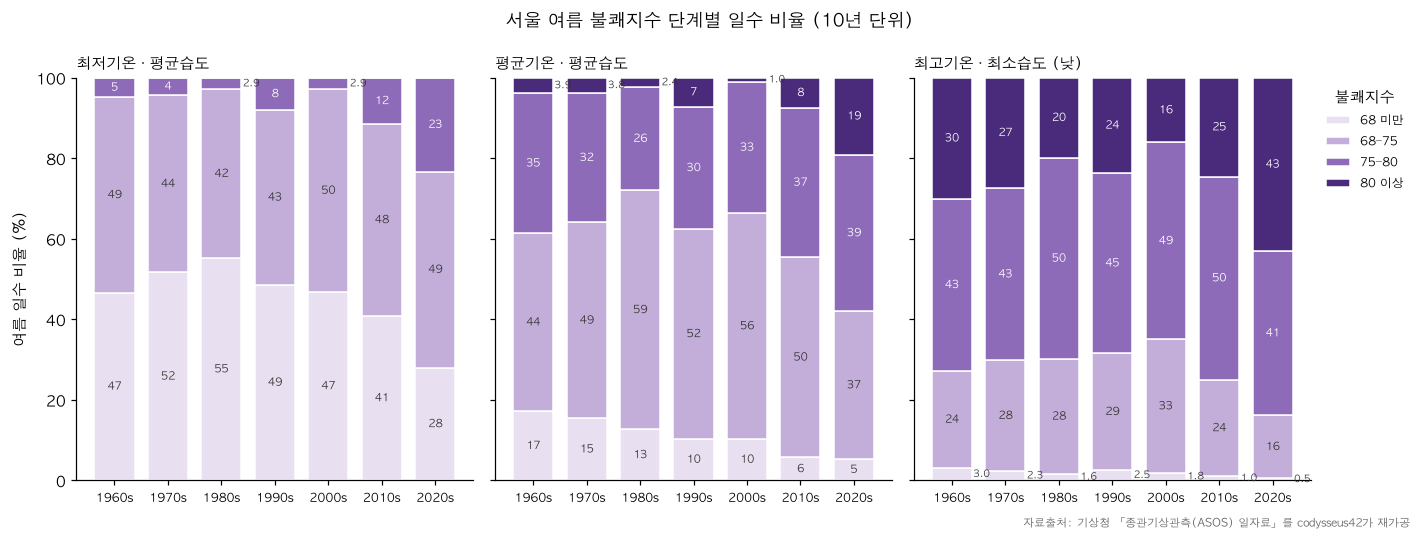

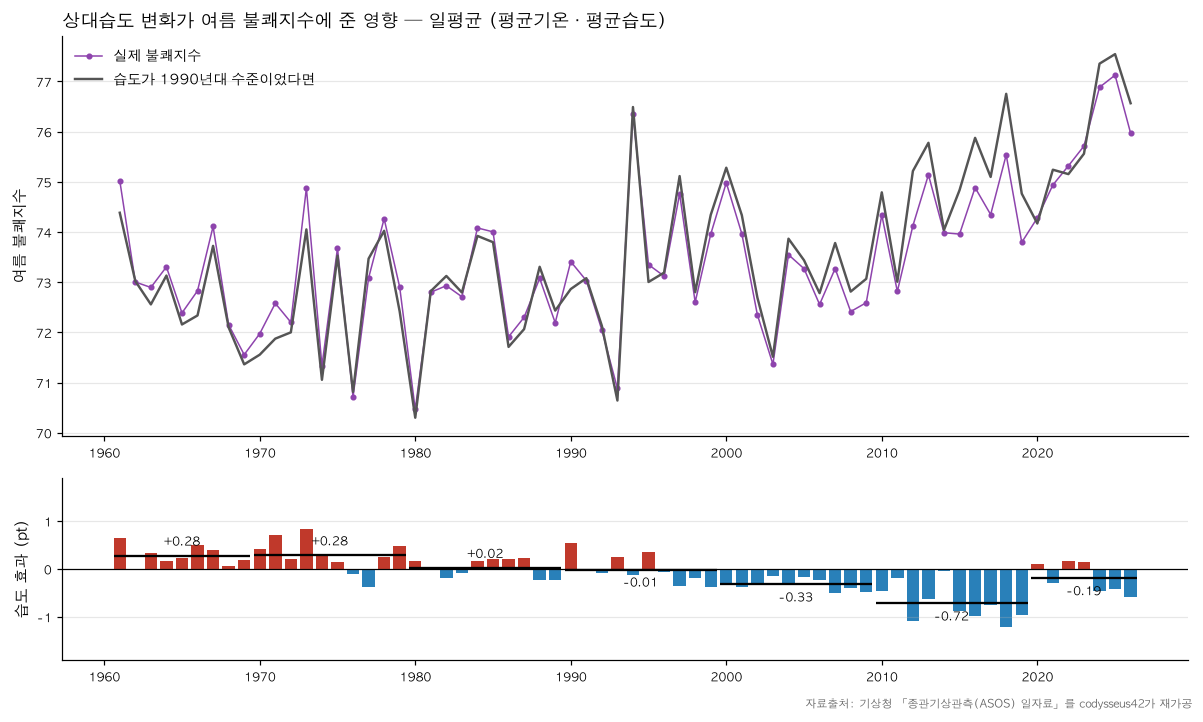

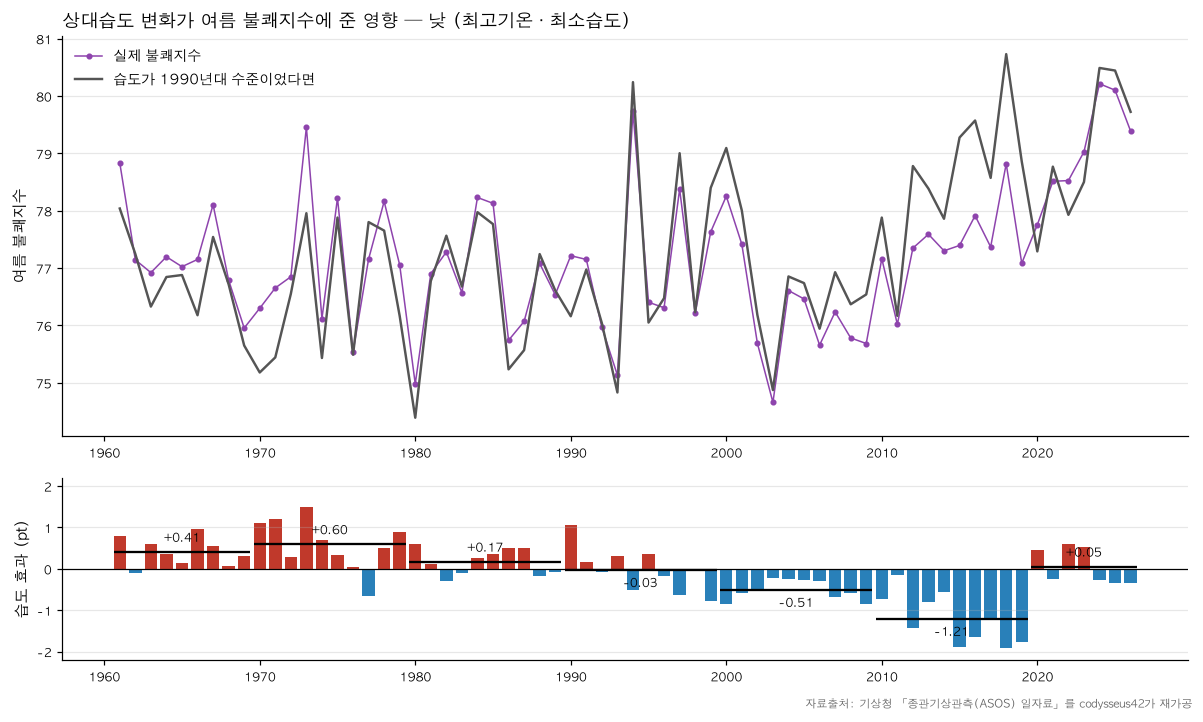

In [5]:
s["year"]   = s.index.year
s["decade"] = s.year // 10 * 10
ref90 = s[s.decade == 1990]
# 해마다 그해 습도를 1990년대 평균 수준으로 옮긴다 (그해 평균 − 1990년대 평균을 모든 날에서 뺀다)
s["rh_1990s"]     = s.groupby("year").rh.transform(lambda x: shift_rh(x, ref90.rh))
s["rh_min_1990s"] = s.groupby("year").rh_min.transform(lambda x: shift_rh(x, ref90.rh_min))
s["di_rh90"]      = discomfort_index(s.tavg, s.rh_1990s)
s["di_day_rh90"]  = discomfort_index(s.tmax, s.rh_min_1990s)
 
print("1960년대와 2020년대 사이의 평균 상승이 임계치 80 이상 분포에 미친 영향")
b, n = s[s.decade == 1960], s[s.decade == 2020]
for c in ["di", "di_day"]:
    shifted = b[c] + (n[c].mean() - b[c].mean())                # 1960년대 분포를 평균만 이동
    print(f"{c:7s} 1960s {(b[c] >= 80).mean()*100:5.1f}%  2020s {(n[c] >= 80).mean()*100:5.1f}%"
          f"  평균만 이동 {(shifted >= 80).mean()*100:5.1f}%")
 
BINS   = [-np.inf, 68, 75, 80, np.inf]
LEVELS = ["68 미만", "68–75", "75–80", "80 이상"]
COLORS = ["#e8e0f0", "#c3aed9", "#8e6bb8", "#4a2a7a"]          # 한 색상, 옅은→짙은
 
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), sharey=True)
for ax, (col, hum, name) in zip(axes, [("tmin", "rh",     "최저기온 · 평균습도"),
                                       ("tavg", "rh",     "평균기온 · 평균습도"),
                                       ("tmax", "rh_min", "최고기온 · 최소습도 (낮)")]):
    level = pd.cut(discomfort_index(s[col], s[hum]), BINS, labels=LEVELS, right=False)
    share = pd.crosstab(s.decade, level, normalize="index").reindex(columns=LEVELS, fill_value=0) * 100
    bottom = np.zeros(len(share))
    x = np.arange(len(share))
    for lv, c in zip(LEVELS, COLORS):
        ax.bar(x, share[lv], bottom=bottom, color=c, width=0.75,
               edgecolor="white", linewidth=1, label=lv)
        for i, v in enumerate(share[lv]):                       # 모든 조각에 수치
            if v == 0:
                continue
            dark = lv in ("75–80", "80 이상")
            if v >= 4:                                          # 안쪽 가운데
                ax.text(i, bottom[i] + v / 2, f"{v:.0f}", ha="center", va="center",
                        fontsize=7.5, color="white" if dark else "#333")
            else:                                               # 얇은 조각은 막대 오른쪽 바깥
                ax.text(i + 0.4, bottom[i] + v / 2, f"{v:.1f}", ha="left", va="center",
                        fontsize=6.5, color="#333")
        bottom += share[lv].values
    ax.set_xticks(x, [f"{d}s" for d in share.index], fontsize=8)
    ax.set_title(name, loc="left", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("여름 일수 비율 (%)")
axes[-1].legend(title="불쾌지수", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=8)
fig.suptitle("서울 여름 불쾌지수 단계별 일수 비율 (10년 단위)", fontsize=12)
fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
plt.tight_layout(rect=(0, 0.01, 1, 1))
plt.savefig("imagedata/fig3_di_levels.png", bbox_inches="tight", dpi=150)
plt.show()

VERSIONS = [
    ("di",     "di_rh90",     "일평균 (평균기온 · 평균습도)", "fig2_rh_counterfactual.png"),
    ("di_day", "di_day_rh90", "낮 (최고기온 · 최소습도)",     "fig2b_rh_counterfactual_day.png"),
]
for act, cf, label, fname in VERSIONS:
    yr_cf = s.groupby("year")[[act, cf]].mean()
    yr_cf["gap"] = yr_cf[act] - yr_cf[cf]                      # + : 습도가 체감을 올림

    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                  gridspec_kw={"height_ratios": [2.2, 1]})
    ax.plot(yr_cf.index, yr_cf[act], "o-", ms=3, lw=1, color="#8e44ad", label="실제 불쾌지수")
    ax.plot(yr_cf.index, yr_cf[cf], "-", lw=1.6, color="#555", label="습도가 1990년대 수준이었다면")
    ax.set_ylabel("여름 불쾌지수")
    ax.set_title(f"상대습도 변화가 여름 불쾌지수에 준 영향 — {label}", loc="left")
    ax.legend(loc="upper left", fontsize=9, frameon=False)

    ax2.bar(yr_cf.index, yr_cf.gap, width=0.8,
            color=np.where(yr_cf.gap >= 0, "#c0392b", "#2980b9"))
    ax2.axhline(0, color="k", lw=0.8)
    for d, g in yr_cf.groupby(yr_cf.index // 10 * 10).gap:     # 10년 평균 가로선
        ax2.hlines(g.mean(), g.index.min() - 0.4, g.index.max() + 0.4, color="k", lw=1.5)
        ax2.annotate(f"{g.mean():+.2f}", (np.mean(g.index), g.mean()),
                     xytext=(0, 4 if g.mean() >= 0 else -4), textcoords="offset points",
                     ha="center", va="bottom" if g.mean() >= 0 else "top", fontsize=8)
    ax2.set_ylabel("습도 효과 (pt)")
    lim = max(1.9, yr_cf.gap.abs().max() * 1.15)               # 낮 버전은 폭이 더 커서 자동 조정
    ax2.set_ylim(-lim, lim)
    for a in (ax, ax2):
        a.xaxis.set_major_locator(MultipleLocator(10))
        a.tick_params(labelbottom=True, labelsize=8)
        a.grid(alpha=0.3, axis="y")
        a.spines[["top", "right"]].set_visible(False)
    fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
    plt.tight_layout(rect=(0, 0.01, 1, 1))
    plt.savefig(f"imagedata/{fname}", bbox_inches="tight", dpi=150)
    plt.show()



### 2010년대와 2020년대의 비교 — 가설 2: 기억 가설

반면 여름 연평균 그래프에서 2010년대의 습도가 눈에 띄게 낮다.

- 관찰: 서울 여름 평균 상대습도는 2010년대 68.7%로 관측 기간 중 가장 낮은 10년이었다.
  최소 상대습도도 2010년대 48.3%로 66년 평균(55.8%)보다 7.5%p 낮았고, 2020년대에는 56.6%로 평년 수준을 회복했다.

사람들이 최근의 경험을 비교 대상으로 삼는다는 점을 감안하면, 2020년대의 여름을 유난히 건조했던 2010년대의 기억과
대조하고 있는 것은 아닐까? 특히 습도 불쾌감 주장을 인터넷에서 많이 접했다는 점에서, 인터넷 이용이 활발한 1990년대생과 2000년대생이 주장의 주된 화자라고 가정하면,
1990년대생과 2000년대생에게는 생애에서 2010년대 여름의 비중 자체가 크다는 점도 고려할 수 있다.
(이 부분은 인구·인식 자료가 없어 검증할 수 없는 가설이다.)

아래 그래프는 2010년대를 기준으로 2020년대를 비교한 것이다. 1990년대 기준과 달리 습도 몫이 크게 나타난다.

| 2010년대 → 2020년대 | 평균 변화 | 습도 몫 | 80 이상 비율 변화 | 습도 몫 |
|---|---|---|---|---|
| 일평균 불쾌지수 | +1.45 | +0.57 (39%) | +11.6%p | +5.6%p (48%) |
| 낮 불쾌지수 | +1.68 | +1.28 (76%) | +18.5%p | +10.7%p (58%) |

*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*

- 해석: 같은 2020년대라도 1990년대와 비교하면 습도 몫이 4%, 2010년대와 비교하면 76%다(낮 불쾌지수 기준).
  "최근 여름이 습해서 더 힘들다"는 체감은, 유난히 건조했던 직전 10년과 비교할 때 가장 잘 성립한다.

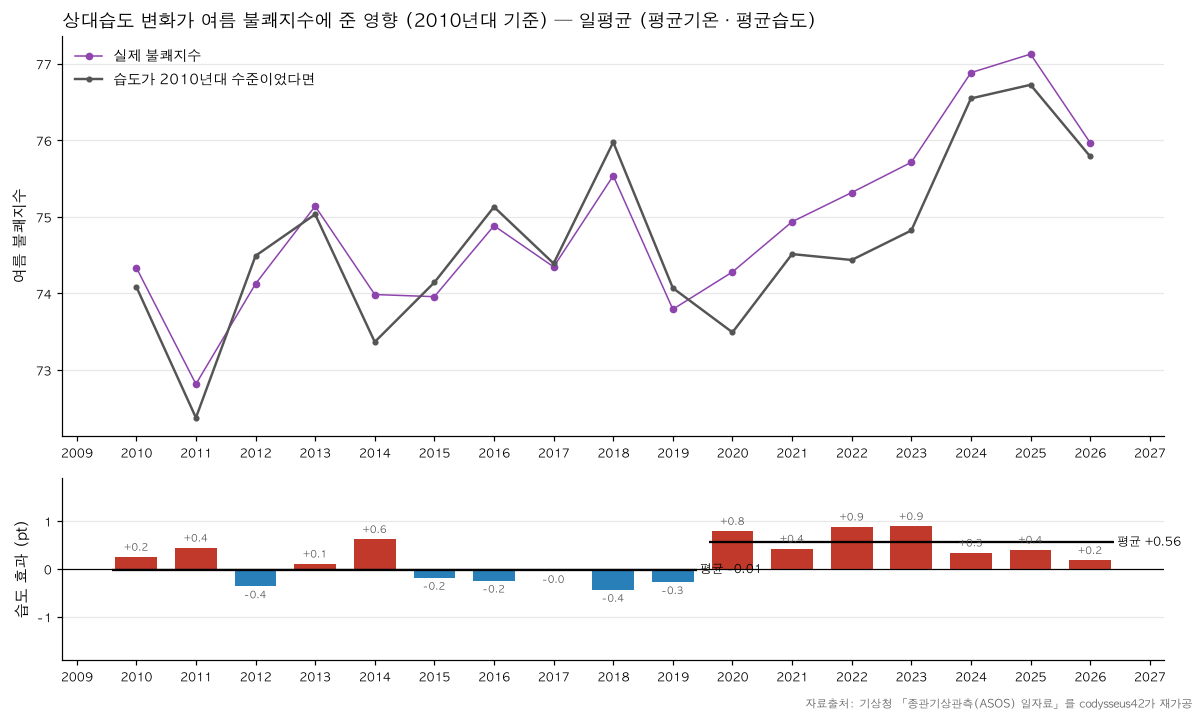

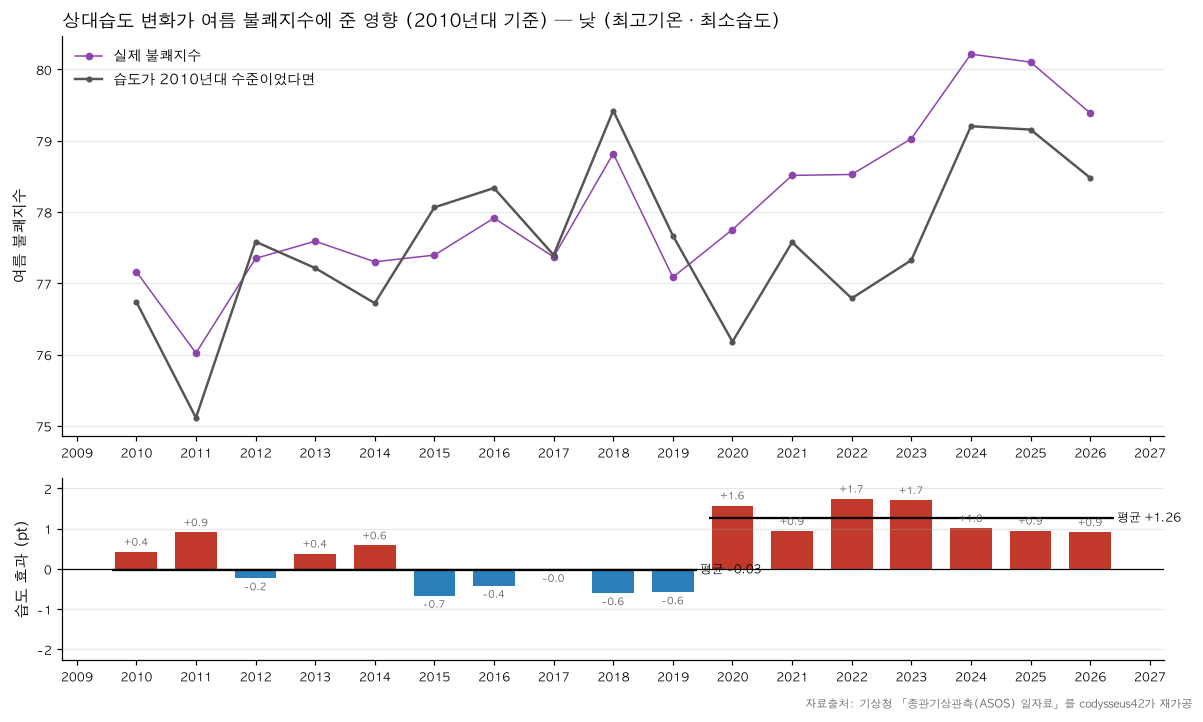

In [6]:
CF_BASE, FROM = 2010, 2010

ref10 = s[s.decade == CF_BASE]
s10 = s[s.year >= FROM].copy()
s10["di_rh10"]     = discomfort_index(s10.tavg, s10.groupby("year").rh.transform(lambda x: shift_rh(x, ref10.rh)))
s10["di_day_rh10"] = discomfort_index(s10.tmax, s10.groupby("year").rh_min.transform(lambda x: shift_rh(x, ref10.rh_min)))

VERSIONS_10 = [
    ("di",     "di_rh10",     "일평균 (평균기온 · 평균습도)", "fig2c_rh10_counterfactual.png"),
    ("di_day", "di_day_rh10", "낮 (최고기온 · 최소습도)",     "fig2d_rh10_counterfactual_day.png"),
]
for act, cf, label, fname in VERSIONS_10:
    yr_cf = s10.groupby("year")[[act, cf]].mean()
    yr_cf["gap"] = yr_cf[act] - yr_cf[cf]

    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                  gridspec_kw={"height_ratios": [2.2, 1]})
    ax.plot(yr_cf.index, yr_cf[act], "o-", ms=4, lw=1, color="#8e44ad", label="실제 불쾌지수")
    ax.plot(yr_cf.index, yr_cf[cf], "o-", ms=3, lw=1.6, color="#555", label=f"습도가 {CF_BASE}년대 수준이었다면")
    ax.set_ylabel("여름 불쾌지수")
    ax.set_title(f"상대습도 변화가 여름 불쾌지수에 준 영향 ({CF_BASE}년대 기준) — {label}", loc="left")
    ax.legend(loc="upper left", fontsize=9, frameon=False)

    ax2.bar(yr_cf.index, yr_cf.gap, width=0.7,
            color=np.where(yr_cf.gap >= 0, "#c0392b", "#2980b9"))
    ax2.axhline(0, color="k", lw=0.8)
    for d, g in yr_cf.groupby(yr_cf.index // 10 * 10).gap:     # 10년 평균 가로선
        ax2.hlines(g.mean(), g.index.min() - 0.4, g.index.max() + 0.4, color="k", lw=1.5)
        ax2.text(g.index.max() + 0.45, g.mean(), f"평균 {g.mean():+.2f}",
                 ha="left", va="center", fontsize=8)
    for yy, v in yr_cf.gap.items():                             # 연도별 값
        ax2.annotate(f"{v:+.1f}", (yy, v), xytext=(0, 2 if v >= 0 else -2), textcoords="offset points",
                     ha="center", va="bottom" if v >= 0 else "top", fontsize=6.5, color="#555")
    ax2.set_ylabel("습도 효과 (pt)")
    lim = max(1.9, yr_cf.gap.abs().max() * 1.3)
    ax2.set_ylim(-lim, lim)
    for a in (ax, ax2):
        a.xaxis.set_major_locator(MultipleLocator(1))           # 1년 단위 눈금
        a.tick_params(labelbottom=True, labelsize=8)
        a.grid(alpha=0.3, axis="y")
        a.spines[["top", "right"]].set_visible(False)
    fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
    plt.tight_layout(rect=(0, 0.01, 1, 1))
    plt.savefig(f"imagedata/{fname}", bbox_inches="tight", dpi=150)
    plt.show()
    




### 기준 시기별 비교와 Q1 소결

1990년대, 2000년대, 2010년대를 각각 기준 시기로 두고, 2020년대의 습도만 기준 시기 수준으로 옮겼을 때
불쾌지수가 얼마나 달라지는지로 습도 몫을 계산하였다.

아래 셀의 첫 번째 표는 가설 2의 2010년대 원인 분해, 두 번째 표는 위 비중 표의 원자료(기준 시기별 원인 분해),
세 번째 표는 가설 2의 관찰에 쓴 서울 10년 단위 습도다.

| 기준 시기 | 일평균 불쾌지수 평균 | 일평균 80 이상 일수 | 낮 불쾌지수 평균 | 낮 80 이상 일수 |
|---|---|---|---|---|
| 1990년대 | −8% | −16% | 4% | 2% |
| 2000년대 | 7% | 12% | 22% | 17% |
| 2010년대 | 39% | 48% | 76% | 58% |

*표의 값은 2020년대 변화 중 습도 비중. 자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*

- 관찰: 1990년대와 비교하면 습도 몫은 없거나 오히려 음수였다. 기준 시기를 2000년대, 2010년대로 옮길수록
  습도 몫이 커졌고, 2010년대를 기준으로 하면 뚜렷하게 커지며 특히 낮 불쾌지수에서 두드러졌다(76%).
- 해석: 2010년대를 기준으로 하면 가설 1도 성립한다. 습도는 불쾌지수 전반뿐 아니라
  높은 불쾌감을 주는 날의 증가에도 절반 이상 기여했다. 같은 2020년대를 두고 기준 시기에 따라 결론이 뒤집히므로,
  "습해서 더 힘들다"는 체감은 유난히 건조했던 직전 10년과 비교할 때 가장 잘 성립한다.


2010년대 → 2020년대 서울 원인 분해 (pt: 평균, %p: 80 이상 일수 비율)


,지표,단위,2010s,2020s,변화,습도 몫,기온 몫,습도 비중(%)
0,일평균 불쾌지수,pt,74.29,75.75,1.45,0.57,0.88,39.23
1,낮 불쾌지수,pt,77.40,79.08,1.68,1.28,0.40,76.31
2,일평균 80 이상 일수,%p,7.50,19.13,11.63,5.60,6.03,48.14
3,낮 80 이상 일수,%p,24.57,43.08,18.51,10.73,7.78,57.96


*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*


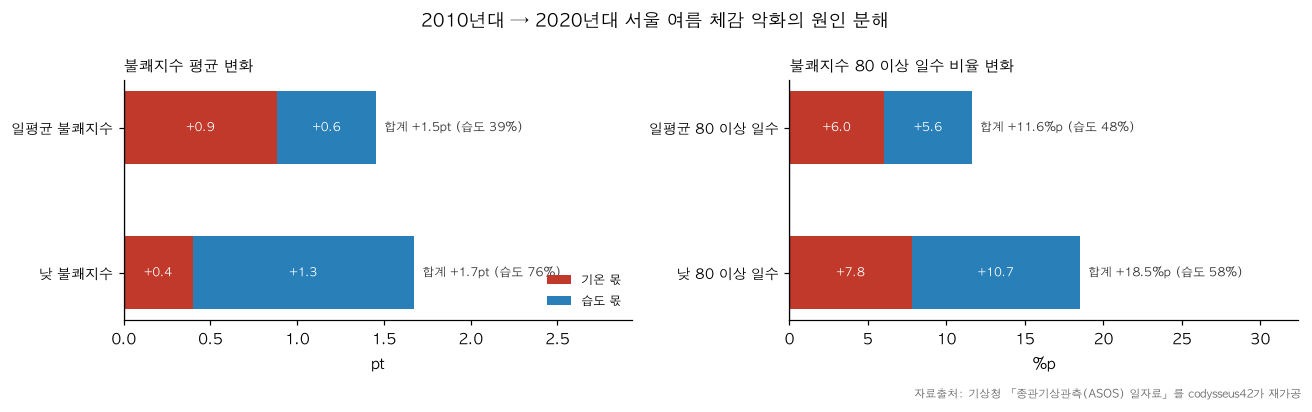

기준 시기별 원인 분해 — 서울, 2020년대와 비교


,기준 시기,지표,습도 변화(%p),기온 변화(°C),불쾌지수 변화,습도 몫,습도 비중(%),80 이상 비율 변화(%p),80 이상 습도 몫(%p),80 이상 습도 비중(%)
0,1990s,일평균 불쾌지수,-1.58,1.67,2.40,-0.18,-7.54,11.96,-1.87,-15.61
1,1990s,낮 불쾌지수,0.47,1.43,2.06,0.07,3.51,19.38,0.31,1.60
2,2000s,일평균 불쾌지수,1.73,1.65,2.72,0.20,7.27,18.15,2.18,12.00
3,2000s,낮 불쾌지수,4.11,1.63,2.83,0.63,22.36,26.99,4.67,17.29
4,2010s,일평균 불쾌지수,4.99,0.60,1.45,0.57,39.23,11.63,5.60,48.14
5,2010s,낮 불쾌지수,8.31,0.30,1.68,1.28,76.31,18.51,10.73,57.96


*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*
서울 10년 단위 여름 평균 상대습도·최소 상대습도(%)


decade,1960,1970,1980,1990,2000,2010,2020
rh,78.2,78.3,75.5,75.3,72.0,68.7,73.7
rh_min,59.2,60.6,57.5,56.2,52.5,48.3,56.6


*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*
66년 평균  상대습도 74.5%  최소 상대습도 55.8%


In [7]:


BASE, NOW = 2010, 2020                                          # 기준: 직전 10년

# 2020년대에서 습도만 2010년대 수준으로 옮김 (기온은 그대로)
prev = s[s.decade == BASE]
now  = s[s.decade == NOW].copy()
now["di_cf"]     = discomfort_index(now.tavg, shift_rh(now.rh, prev.rh))
now["di_day_cf"] = discomfort_index(now.tmax, shift_rh(now.rh_min, prev.rh_min))

metrics = [   # (이름, 단위, 2010s 실제, 2020s 실제, 2020s 중 습도만 2010s)
    ("일평균 불쾌지수",     "pt", prev.di.mean(),     now.di.mean(),     now.di_cf.mean()),
    ("낮 불쾌지수",         "pt", prev.di_day.mean(), now.di_day.mean(), now.di_day_cf.mean()),
    ("일평균 80 이상 일수", "%p", (prev.di >= 80).mean()*100,     (now.di >= 80).mean()*100,     (now.di_cf >= 80).mean()*100),
    ("낮 80 이상 일수",     "%p", (prev.di_day >= 80).mean()*100, (now.di_day >= 80).mean()*100, (now.di_day_cf >= 80).mean()*100),
]
tbl = pd.DataFrame([{"지표": n, "단위": u, f"{BASE}s": a, f"{NOW}s": b,
                     "변화": b - a, "습도 몫": b - c, "기온 몫": c - a,
                     "습도 비중(%)": (b - c) / (b - a) * 100} for n, u, a, b, c in metrics])
print("2010년대 → 2020년대 서울 원인 분해 (pt: 평균, %p: 80 이상 일수 비율)")                     
display(tbl.round(2))
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, unit, title in [(axes[0], "pt", "불쾌지수 평균 변화"),
                        (axes[1], "%p", "불쾌지수 80 이상 일수 비율 변화")]:
    t = tbl[tbl["단위"] == unit].iloc[::-1]
    y = np.arange(len(t))
    ax.barh(y, t["기온 몫"], color="#c0392b", height=0.5, label="기온 몫")
    ax.barh(y, t["습도 몫"], left=t["기온 몫"], color="#2980b9", height=0.5, label="습도 몫")
    for i, (_, r) in enumerate(t.iterrows()):
        ax.text(r["기온 몫"] / 2, i, f"{r['기온 몫']:+.1f}", ha="center", va="center", color="white", fontsize=8)
        ax.text(r["기온 몫"] + r["습도 몫"] / 2, i, f"{r['습도 몫']:+.1f}", ha="center", va="center", color="white", fontsize=8)
        ax.text(r["변화"], i, f"  합계 {r['변화']:+.1f}{unit} (습도 {r['습도 비중(%)']:.0f}%)",
                ha="left", va="center", fontsize=8, color="#333")
    ax.set_yticks(y, t["지표"], fontsize=9)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlim(0, t["변화"].max() * 1.75)
    ax.set_xlabel(unit)
    ax.set_title(title, loc="left", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(loc="lower right", fontsize=8, frameon=False)
fig.suptitle(f"{BASE}년대 → {NOW}년대 서울 여름 체감 악화의 원인 분해", fontsize=12)
fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.savefig("imagedata/fig5_2010s_decomp.png", bbox_inches="tight", dpi=150)
plt.show()

# 서울 10년 단위 상대습도 (가설 2의 관찰)
# Q1 — 서울, 기준 시기별
q1_tbl = pd.DataFrame([{"기준 시기": f"{B}s", "지표": name, **decompose(s, B, t, h)}
                       for B in [1990, 2000, 2010]
                       for name, t, h in [("일평균 불쾌지수", "tavg", "rh"), ("낮 불쾌지수", "tmax", "rh_min")]])
print("기준 시기별 원인 분해 — 서울, 2020년대와 비교")
display(q1_tbl.round(2))
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")
# 서울 10년 단위 상대습도 (가설 2의 관찰)
print("서울 10년 단위 여름 평균 상대습도·최소 상대습도(%)")
display(s.groupby("decade")[["rh", "rh_min"]].mean().round(1).T)
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")
print(f"66년 평균  상대습도 {s.rh.mean():.1f}%  최소 상대습도 {s.rh_min.mean():.1f}%")

## Q2 동일한 분석을 다른 지역 데이터에 적용하여 서울과 다른 차이를 볼 수 있을까? — 대구, 추풍령

Q1에서 서울은 기준 시기에 따라 결론이 갈렸고, 그 중심에는 유난히 건조했던 2010년대가 있었다.
그렇다면 이것은 서울만의 현상일까? 다른 지역에도 2010년대 건조기가 있었다면 기억 가설은 더 넓게 성립하고,
없었다면 서울에 한정된 설명이 된다.

비교 지점으로는 두 곳을 골랐다.
- 대구: 세 지점 중 기온이 가장 높고 습도가 가장 낮다. 습도가 불쾌감의 주원인이라면 대구는 덜 불쾌해야 한다.
- 추풍령: 도시화가 적은 내륙 고지대로, 도시의 영향이 적은 비교 지점이다.

세 지점 모두 핵심 항목이 있는 공통 유효일만 사용하고, 낮 불쾌지수(최고기온 · 최소 상대습도)를 기준으로 한다.

**진행 순서**
1. 비교 대상 데이터 — 공통 유효일
2. 지점별 추세 — 대구, 추풍령을 서울(Q1)과 같은 형식으로
3. 세 지점 겹쳐 보기 — 앞의 결과를 한 축에서 확인
4. 지점별 원인 분해(1990년대 / 2010년대 기준)와 Q2 소결

**요약**
- 가장 건조한 대구의 낮 불쾌지수가 가장 높아, 지역 간 차이도 습도보다 기온이 결정한다.
- 1990년대 기준으로는 대구와 추풍령에서 습도 변화가 오히려 불쾌지수를 낮추는 쪽으로 작용했다.
- 가설 2(기억 가설)는 서울에서만 설득력이 있다.

### 비교 대상 데이터
세 지점 모두 핵심 항목이 있는 공통 유효일(23,987일)만 사용한다.

In [8]:
df_chupungnyeong = df[df.stn_name == "추풍령"].copy()
df_daegu = df[df.stn_name == "대구"].copy()

stations = {"서울": df_seoul, "추풍령": df_chupungnyeong, "대구": df_daegu}

# 3지점 모두 유효한 날짜만
common = df_seoul.index.intersection(df_chupungnyeong.index).intersection(df_daegu.index)

print(f"3지점 공통 유효일 {len(common):,}일  ({common.min():%Y-%m-%d} ~ {common.max():%Y-%m-%d})")
for name, d in stations.items():
    dropped = d.index.difference(common)                        # 다른 지점 사정으로 빠지는 날
    print(f"  {name:4s} {len(d):,}일 → 제외 {len(dropped)}일  {[f'{x:%Y-%m-%d}' for x in dropped]}")

df_seoul_cmpr         = df_seoul.loc[common].copy()
df_chupungnyeong_cmpr = df_chupungnyeong.loc[common].copy()
df_daegu_cmpr         = df_daegu.loc[common].copy()

assert len(df_seoul_cmpr) == len(df_chupungnyeong_cmpr) == len(df_daegu_cmpr) == len(common)

df_cmpr = df[df.index.isin(common) & df.stn_name.isin(stations)].copy()


3지점 공통 유효일 23,987일  (1961-01-01 ~ 2026-09-13)
  서울   23,994일 → 제외 7일  ['1990-01-01', '2002-02-14', '2013-09-30', '2016-04-11', '2023-03-26', '2024-02-21', '2025-01-09']
  추풍령  23,993일 → 제외 6일  ['2013-09-30', '2017-10-12', '2022-08-08', '2023-03-26', '2024-02-21', '2025-01-09']
  대구   23,992일 → 제외 5일  ['1990-01-01', '2002-02-14', '2016-04-11', '2017-10-12', '2022-08-08']


### 지점별 추세 (추풍령, 대구)
서울(Q1 그림)과 같은 형식으로 최고기온, 최소 상대습도, 낮 불쾌지수의 여름 연평균 추세를 그렸다.
대구 그림의 점선은 관측소 이전 시점(2017년 8월)이다.
볼 것은 두 가지다.
- 최소 상대습도: 세 지점 모두 66년간 낮아졌다(대구 −1.22, 추풍령 −0.77 %p/10년, 서울 −1.65).
  다만 서울처럼 2010년대에 깊게 내려갔다가 2020년대에 올라오는 모양이 대구와 추풍령에도 있는지가 핵심이다.
- 낮 불쾌지수: 습도가 낮아졌는데도 오르는지, 오른다면 최고기온과 같이 움직이는지 본다.

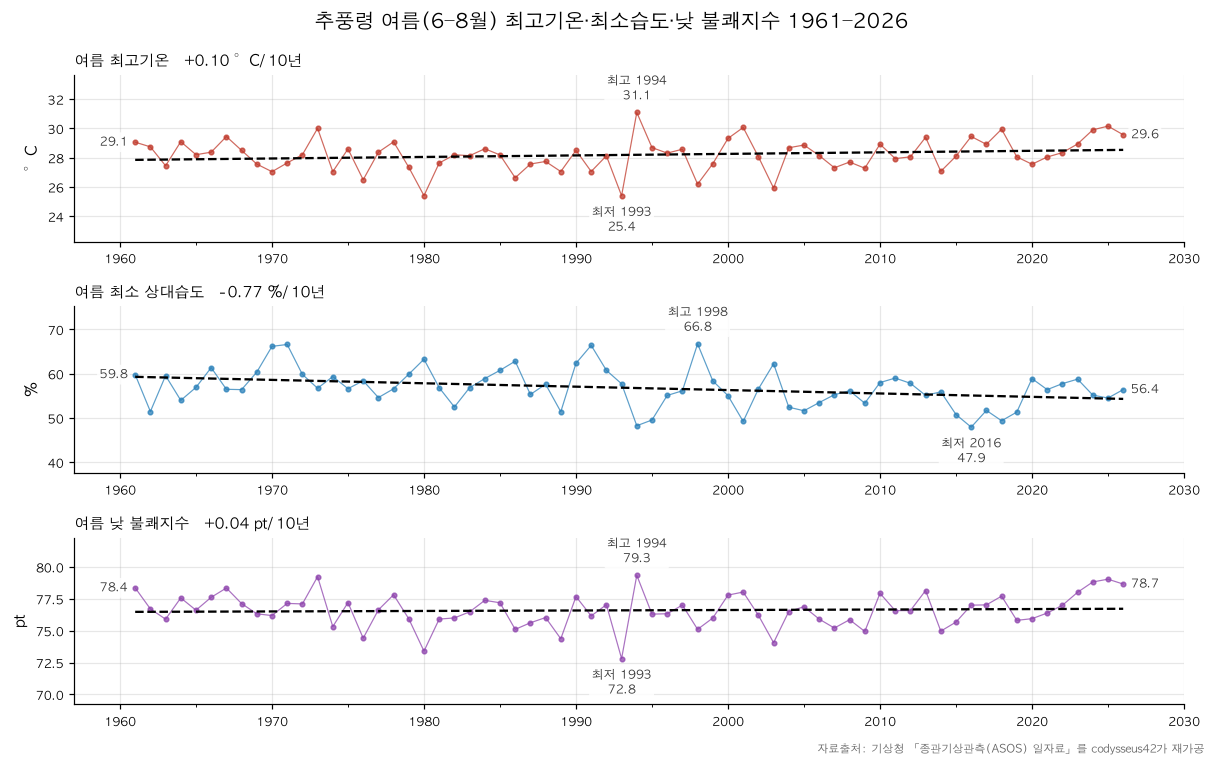

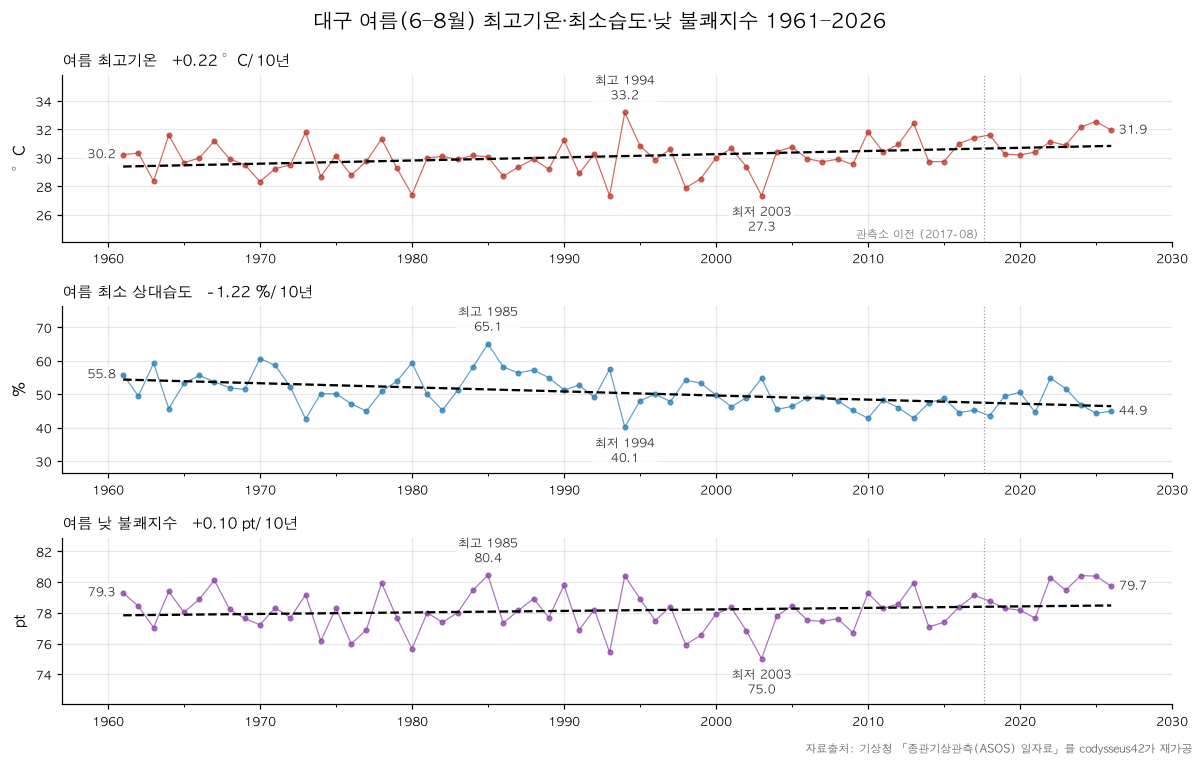

In [9]:
panels_stn = [
    ("tmax",   "여름 최고기온",      "°C", "#c0392b"),
    ("rh_min", "여름 최소 상대습도", "%",  "#2980b9"),
    ("di_day", "여름 낮 불쾌지수",   "pt", "#8e44ad"),
]
FILE = {"추풍령": "chupungnyeong", "대구": "daegu"}

for name, d in [("추풍령", df_chupungnyeong_cmpr), ("대구", df_daegu_cmpr)]:
    ss = d[d.index.month.isin(SUMMER)]
    yr_s = ss.groupby(ss.index.year)[[c for c, *_ in panels_stn]].mean().loc[1961:2026]

    fig, axes = plt.subplots(len(panels_stn), 1, figsize=(11, 2.1 * len(panels_stn) + 0.6), sharex=True)
    for ax, (col, title, unit, c) in zip(axes, panels_stn):
        y = yr_s[col]
        ax.plot(y.index, y, "o-", ms=3, lw=0.8, color=c, alpha=0.75)
        k, b = np.polyfit(y.index, y, 1)
        ax.plot(y.index, k * y.index + b, "k--", lw=1.5)

        lo, hi = y.min(), y.max()
        span = hi - lo
        ax.set_ylim(lo - span * 0.55, hi + span * 0.45)

        ymax, ymin = y.idxmax(), y.idxmin()
        ax.annotate(f"최고 {ymax}\n{y[ymax]:.1f}", (ymax, y[ymax]), xytext=(0, 6),  va="bottom", **LABEL)
        ax.annotate(f"최저 {ymin}\n{y[ymin]:.1f}", (ymin, y[ymin]), xytext=(0, -6), va="top",    **LABEL)

        x0, x1 = y.index[0], y.index[-1]
        ax.annotate(f"{y[x0]:.1f}", (x0, y[x0]), xytext=(-5, 0), va="center", **{**LABEL, "ha": "right"})
        ax.annotate(f"{y[x1]:.1f}", (x1, y[x1]), xytext=(5, 0),  va="center", **{**LABEL, "ha": "left"})

        ax.set_title(f"{title}   {k*10:+.2f} {unit}/10년", loc="left", fontsize=10)
        ax.set_ylabel(unit)
        ax.set_xlim(x0 - 4, x1 + 4)
        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(MultipleLocator(5))
        ax.tick_params(labelbottom=True, labelsize=8)
        ax.grid(alpha=0.3, which="major")
        ax.spines[["top", "right"]].set_visible(False)
        if name == "대구":
            ax.axvline(2017.6, color="#999", lw=0.8, ls=":")      # 관측소 이전
    if name == "대구":
        axes[0].text(2017.3, axes[0].get_ylim()[0], "관측소 이전 (2017-08)", ha="right", va="bottom",
                     fontsize=7, color="#777")

    fig.suptitle(f"{name} 여름(6–8월) 최고기온·최소습도·낮 불쾌지수 1961–2026", fontsize=13)
    fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
    plt.tight_layout(rect=(0, 0.01, 1, 1))
    plt.savefig(f"imagedata/fig_q2_{FILE[name]}.png", bbox_inches="tight", dpi=150)
    plt.show()


### 세 지점 한눈에 비교 — 최고기온, 최소습도, 낮 불쾌지수

앞의 지점별 그림을 한 축에 겹쳤다. 개별 그림에서 본 두 가지를 확인한다.
그림 아래 표는 2020년대(2020~2026년) 여름의 지점별 평균이다.

- 관찰: 2020년대 여름 대구는 최소 상대습도가 48.2%로 가장 낮지만, 낮 불쾌지수는 79.4로 가장 높다(서울 79.1, 추풍령 77.7).
- 해석: 불쾌지수의 지역 차이도 습도보다 기온이 결정한다.
- 관찰: 2010년대 최소 상대습도의 골은 서울에서 가장 깊다.
- 해석: 기억 가설의 전제인 "건조했던 2010년대"는 서울에서 가장 뚜렷하다. 크기는 다음 절의 원인 분해로 확인한다.

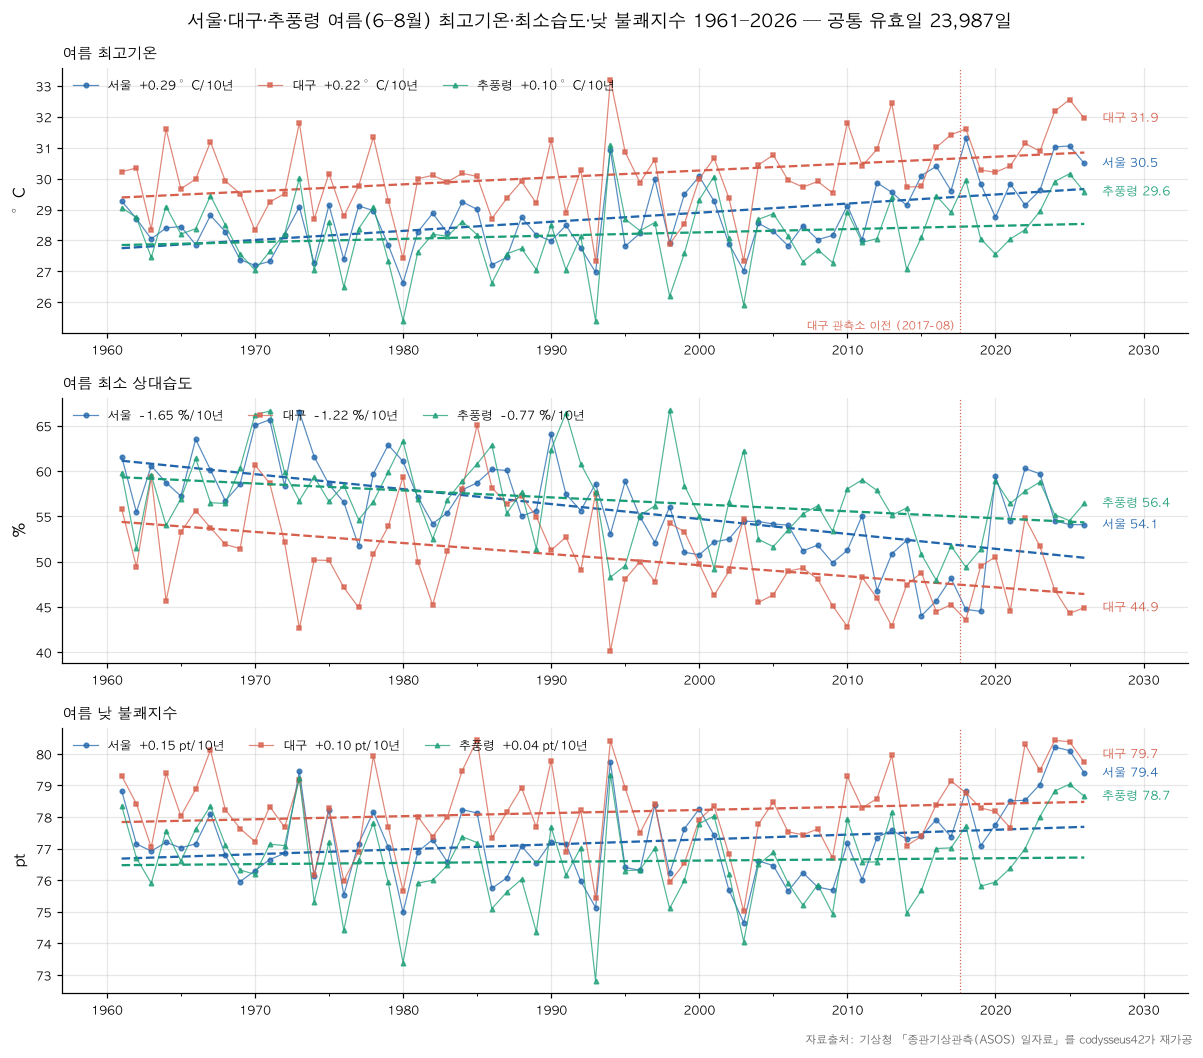

2020년대 여름 지점별 평균 — 최고기온(°C), 최소 상대습도(%), 낮 불쾌지수


,tmax,rh_min,di_day
stn_name,,,
대구,31.3,48.2,79.4
서울,30.0,56.6,79.1
추풍령,28.9,56.9,77.7


*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*


In [10]:

STN_COLOR = {"서울": "#2166ac", "대구": "#d6604d", "추풍령": "#1b9e77"}   # Q2 전체에서 고정
STN_MARK  = {"서울": "o", "대구": "s", "추풍령": "^"}
ROWS = [("tmax",   "여름 최고기온",     "°C"),
        ("rh_min", "여름 최소 상대습도", "%"),
        ("di_day", "여름 낮 불쾌지수",   "pt")]

q2 = df_cmpr[df_cmpr.index.month.isin(SUMMER)]
yr_q2 = q2.groupby([q2.stn_name, q2.index.year])[[c for c, _, _ in ROWS]].mean()

fig, axes = plt.subplots(len(ROWS), 1, figsize=(11, 3.2 * len(ROWS)), sharex=True)
for ax, (col, title, unit) in zip(axes, ROWS):
    ends = []
    for name, c in STN_COLOR.items():
        y = yr_q2.loc[name, col]
        k, b = np.polyfit(y.index, y, 1)
        ax.plot(y.index, y, marker=STN_MARK[name], ms=3, lw=0.8, color=c, alpha=0.75,
                label=f"{name}  {k*10:+.2f} {unit}/10년")
        ax.plot(y.index, k * y.index + b, "--", lw=1.5, color=c)
        ends.append((y.iloc[-1], f"{name} {y.iloc[-1]:.1f}", c, y.index[-1]))
    ends.sort()                                                  # 끝값 라벨 겹침 방지
    gap = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.07
    for i, (v, txt, c, x1) in enumerate(ends):
        v_adj = max(v, ends[i-1][0] + gap) if i else v
        ends[i] = (v_adj, txt, c, x1)
        ax.annotate(txt, (x1, v), xytext=(x1 + 1.2, v_adj), textcoords="data",
                    fontsize=8, color=c, va="center")
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel(unit)
    ax.set_xlim(1957, 2033)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.tick_params(labelbottom=True, labelsize=8)
    ax.grid(alpha=0.3, which="major")
    ax.spines[["top", "right"]].set_visible(False)
    ax.axvline(2017.6, color="#d6604d", lw=0.8, ls=":")          # 대구 관측소 이전
    ax.legend(fontsize=8, frameon=False, loc="upper left", ncol=3)
axes[0].text(2017.3, axes[0].get_ylim()[0], "대구 관측소 이전 (2017-08)", ha="right", va="bottom",
             fontsize=7, color="#d6604d")
fig.suptitle(f"서울·대구·추풍령 여름(6–8월) 최고기온·최소습도·낮 불쾌지수 1961–2026 — 공통 유효일 {len(common):,}일", fontsize=12)
fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
plt.tight_layout(rect=(0, 0.01, 1, 1))
plt.savefig("imagedata/fig_q2_regions.png", bbox_inches="tight", dpi=150)
plt.show()

print("2020년대 여름 지점별 평균 — 최고기온(°C), 최소 상대습도(%), 낮 불쾌지수")
now_lv = df_cmpr[df_cmpr.index.month.isin(SUMMER) & (df_cmpr.index.year >= 2020)]
display(now_lv.groupby("stn_name")[["tmax", "rh_min", "di_day"]].mean().round(1))
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")

### 지점별 원인 분해 — 습도 비중 (기준 1990년대 / 2010년대)
첫 번째 표는 10년 단위 여름 최소 상대습도다. 1990년대는 세 지점 모두 66년 평균과 1.3%p 이내여서 평년 기준으로,
2010년대는 직전 10년으로 비교 기준 시기를 정했다.

두 번째 표와 그림은 2020년대의 습도만 기준 시기 수준으로 옮겨, 낮 불쾌지수의 변화를 기온 몫과 습도 몫으로 나눈 것이다
(pt: 평균의 변화, %p: 80 이상 일수 비율의 변화).

- 관찰: 2010년대에서 2020년대로 넘어오며 최소 상대습도가 오른 폭은 서울 +8.3%p, 대구 +2.3%p, 추풍령 +3.2%p다.
  습도 몫은 서울 1.28pt로, 대구(0.39pt)와 추풍령(0.45pt)의 약 3배다. 1990년대 기준으로는 대구와 추풍령의 습도 몫이 음수다.
- 해석: 대구와 추풍령은 불쾌지수 상승분 자체가 작아(1pt 미만) 비중(%)은 40% 안팎으로 나오지만, 실제 습도 몫은 작다.
  2010년대와 2020년대의 습도 차이가 크지 않아 가설 2의 전제가 약하며, 가설 2는 서울에서만 설득력이 있다.

10년 단위 여름 최소 상대습도(%)와 66년 평균 — 3지점 공통 유효일


decade,1960,1970,1980,1990,2000,2010,2020,66년 평균
stn_name,,,,,,,,
대구,52.9,51.1,55.5,50.4,48.3,45.9,48.2,50.4
서울,59.2,60.6,57.5,56.2,52.5,48.3,56.6,55.8
추풍령,57.4,59.5,57.6,58.1,54.5,53.7,56.9,56.8


*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*
지점별 원인 분해 — 낮 불쾌지수, 기준 1990년대 / 2010년대


,지점,기준,단위,변화,습도 몫,기온 몫,습도 비중(%)
0,서울,1990s,pt,2.06,0.07,1.99,3.51
1,서울,1990s,%p,19.38,0.31,19.07,1.60
2,서울,2010s,pt,1.68,1.28,0.40,76.31
3,서울,2010s,%p,18.51,10.73,7.78,57.96
4,대구,1990s,pt,1.65,-0.36,2.01,-22.07
5,대구,1990s,%p,15.39,-1.56,16.95,-10.11
6,대구,2010s,pt,0.93,0.39,0.54,41.95
7,대구,2010s,%p,10.72,2.64,8.07,24.67
8,추풍령,1990s,pt,1.32,-0.19,1.50,-14.10
9,추풍령,1990s,%p,10.80,-1.40,12.20,-12.96


*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*


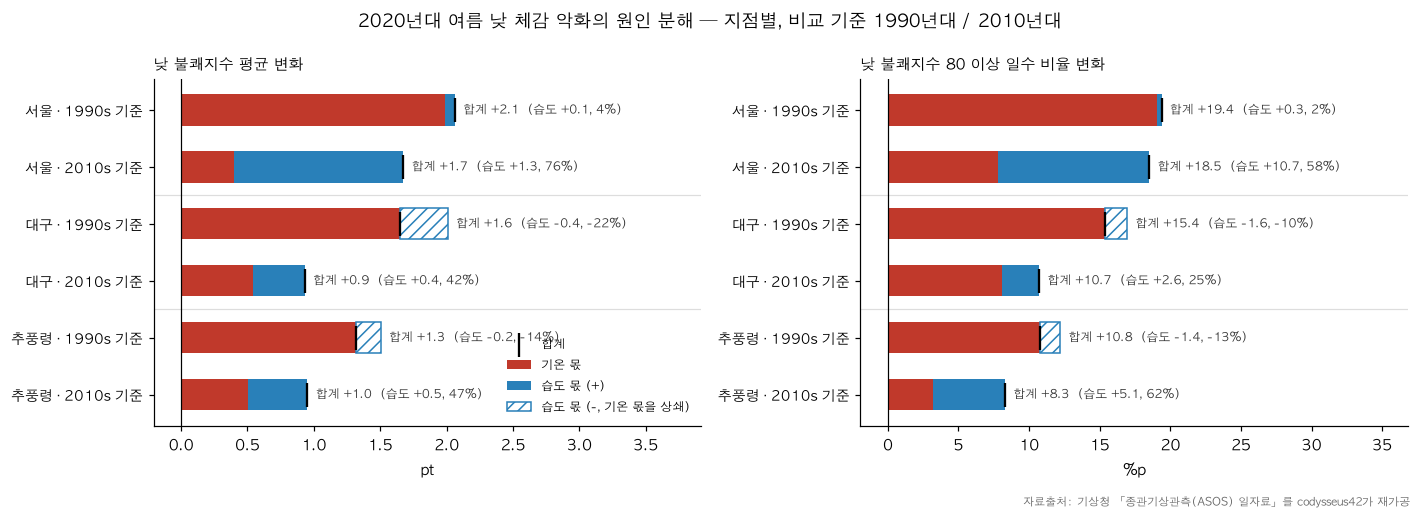

In [11]:
q = df_cmpr[df_cmpr.index.month.isin(SUMMER)].copy()
q["decade"] = q.index.year // 10 * 10

# 기준 시기 선정 근거: 10년 단위 여름 최소습도와 66년 평균
rh_dec = q.groupby(["stn_name", "decade"]).rh_min.mean().unstack()
rh_dec["66년 평균"] = q.groupby("stn_name").rh_min.mean()
print("10년 단위 여름 최소 상대습도(%)와 66년 평균 — 3지점 공통 유효일")
display(rh_dec.round(1))
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")

rows = []
for name in ["서울", "대구", "추풍령"]:
    d = q[q.stn_name == name]
    now_q = d[d.decade == 2020]
    for B in [1990, 2010]:
        prev_q = d[d.decade == B]
        cf = discomfort_index(now_q.tmax, shift_rh(now_q.rh_min, prev_q.rh_min))
        total = now_q.di_day.mean() - prev_q.di_day.mean()
        hum = now_q.di_day.mean() - cf.mean()
        tot80 = (now_q.di_day >= 80).mean() - (prev_q.di_day >= 80).mean()
        hum80 = (now_q.di_day >= 80).mean() - (cf >= 80).mean()
        rows.append({"지점": name, "기준": f"{B}s", "낮 불쾌지수 변화": total, "습도 몫(pt)": hum,
                     "습도 비중(%)": hum / total * 100, "80 이상 비율 습도 비중(%)": hum80 / tot80 * 100})

rows = []
for name in ["서울", "대구", "추풍령"]:
    d = q[q.stn_name == name]
    now_q = d[d.decade == 2020]
    for B in [1990, 2010]:
        prev_q = d[d.decade == B]
        cf = discomfort_index(now_q.tmax, shift_rh(now_q.rh_min, prev_q.rh_min))
        a, b, c = prev_q.di_day, now_q.di_day, cf
        rows += [{"지점": name, "기준": f"{B}s", "단위": "pt",
                  "변화": b.mean() - a.mean(), "습도 몫": b.mean() - c.mean(), "기온 몫": c.mean() - a.mean()},
                 {"지점": name, "기준": f"{B}s", "단위": "%p",
                  "변화": ((b >= 80).mean() - (a >= 80).mean()) * 100,
                  "습도 몫": ((b >= 80).mean() - (c >= 80).mean()) * 100,
                  "기온 몫": ((c >= 80).mean() - (a >= 80).mean()) * 100}]
dec_tbl = pd.DataFrame(rows)
dec_tbl["습도 비중(%)"] = dec_tbl["습도 몫"] / dec_tbl["변화"] * 100

print("지점별 원인 분해 — 낮 불쾌지수, 기준 1990년대 / 2010년대")
display(dec_tbl.round(2))
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, unit, title in [(axes[0], "pt", "낮 불쾌지수 평균 변화"),
                        (axes[1], "%p", "낮 불쾌지수 80 이상 일수 비율 변화")]:
    t = dec_tbl[dec_tbl["단위"] == unit].iloc[::-1].reset_index(drop=True)
    y = np.arange(len(t))
    ax.barh(y, t["기온 몫"], color="#c0392b", height=0.55, label="기온 몫")
    pos = t["습도 몫"] >= 0
    ax.barh(y[pos], t["습도 몫"][pos], left=t["기온 몫"][pos], color="#2980b9", height=0.55, label="습도 몫 (+)")
    ax.barh(y[~pos], t["습도 몫"][~pos], left=t["기온 몫"][~pos], facecolor="white", edgecolor="#2980b9",
            hatch="///", height=0.55, label="습도 몫 (-, 기온 몫을 상쇄)")
    ax.scatter(t["변화"], y, marker="|", s=250, color="k", zorder=3, label="합계")
    span = max(t[["기온 몫", "변화"]].abs().max().max(), 1e-9)
    for i, r in t.iterrows():
        right = max(r["기온 몫"], r["변화"], 0)
        ax.text(right + span * 0.03, i, f"합계 {r['변화']:+.1f}  (습도 {r['습도 몫']:+.1f}, {r['습도 비중(%)']:.0f}%)",
                ha="left", va="center", fontsize=8, color="#333")
    ax.set_yticks(y, [f"{a} · {b} 기준" for a, b in zip(t["지점"], t["기준"])], fontsize=9)
    for k in range(1, len(t) // 2):                              # 지점 사이 구분선
        ax.axhline(k * 2 - 0.5, color="#ddd", lw=0.8)
    ax.axvline(0, color="k", lw=0.8)
    lo = min(0, (t["기온 몫"] + t["습도 몫"].clip(upper=0)).min())
    ax.set_xlim(lo - span * 0.1, span * 1.9)
    ax.set_xlabel(unit)
    ax.set_title(title, loc="left", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(loc="lower right", fontsize=8, frameon=False)
fig.suptitle("2020년대 여름 낮 체감 악화의 원인 분해 — 지점별, 비교 기준 1990년대 / 2010년대", fontsize=12)
fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.savefig("imagedata/fig_q2_decomp.png", bbox_inches="tight", dpi=150)
plt.show()


### Q2 소결

- 세 지점 모두 66년간 여름 최소 상대습도가 낮아졌고(서울 −1.65, 대구 −1.22, 추풍령 −0.77 %p/10년),
  1990년대를 기준으로 하면 대구와 추풍령에서는 습도 변화가 오히려 불쾌지수를 낮추는 쪽으로 작용했다.
- 가장 건조한 대구의 낮 불쾌지수가 가장 높아, 지역 간 차이도 습도보다 기온이 결정한다.
- 가설 2는 서울에서만 설득력이 있고, 대구와 추풍령에서는 2010년대와 2020년대의 습도 차이가 작아 설득력을 상당 부분 잃는다.

한계는 다음과 같다.

1. **비교 지점이 세 곳뿐이다.** 서울에서만 2010년대 습도 저점이 깊었던 이유가 도시화 때문인지,
   서울 고유의 지리 조건 때문인지 구분할 수 없다.
2. **대구 관측소는 2017년 8월에 북쪽으로 약 5.5km 이전했다.** 2010년대와 2020년대의 경계에 걸려 있어,
   대구의 2010년대 대비 변화에는 관측 위치의 변화가 섞여 있을 수 있다.
3. **추풍령은 해발 약 245m의 고지대다.** 도시화가 적은 비교 지점이지만 기후 조건 자체가 서울과 달라 순수한 대조군은 아니며,
   기온이 낮아 80 이상인 날의 비율도 원래 적다.
4. **상승분이 작은 지점은 비중(%)이 부풀려 보인다.** 그래서 습도 몫을 크기(pt)와 함께 표기했다.
5. **지역별 인식 자료가 없다.** 대구나 추풍령 주민이 습도를 불쾌감의 원인으로 느끼는지 알 수 없어,
   가설 2가 지방에서 약하다는 결론도 기상 자료만으로 내린 것이다.

## Q3 불쾌지수를 제외한 다른 생활 기후 지표로 분석해보면 다른 결과가 나올까? — 체감온도(기상청), Humidex(캐나다), Heat Index(미국)

Q1, Q2의 결론은 불쾌지수 하나에 기대고 있다. 불쾌지수는 기상청이 2020년 서비스를 종료한 오래된 지표이므로,
현재 쓰이는 다른 체감 지표로 바꿔도 같은 결론이 나오는지 확인한다.
단순화를 위해서 여기서는 임계값과 해석은 제외하고 값에 얼마나 변화를 줄 수 있는지 추세의 변화를 통해서 확인한다.

**진행 순서**
1. 네 가지 체감 지표 — 식, 습도의 무게, 66년 추세, 원인 분해
2. 소결

**요약**
- 네 지표 모두 습도의 무게가 작고(습도 1%p ≈ 기온 0.1°C) 결론도 같다.

### 네 가지 체감 지표

모두 낮 기준(최고기온 T, 최소 상대습도 RH)으로 하루마다 계산했다.

| 지표 | 식 | 출처 |
|---|---|---|
| 불쾌지수 | $0.81T + 0.01RH(0.99T - 14.3) + 46.3$ | Thom (1959) |
| 체감온도(여름) | $-0.2442 + 0.55399T_w + 0.45535T - 0.0022T_w^2 + 0.00278T_wT + 3.0$, $T_w$: 습구온도(Stull, 2011) | 기상청 (2022 개정) |
| Humidex | $T + \frac{5}{9}(e - 10)$, $e = 6.112 \times 10^{7.5T/(237.7+T)} \times RH/100$ | 캐나다 환경청 |
| Heat Index | 화씨 기온과 상대습도의 9항 회귀식(Rothfusz) + 저습·고습 보정 | 미국 기상청(NWS) |

첫 번째 표는 기온 30°C, 습도 55%에서 습도 1%p가 기온 몇 °C에 해당하는지다.
- 관찰: 네 지표 모두 0.09~0.13°C다.
- 해석: 습도가 10%p 변해도 기온 1°C 변화와 비슷하다. 체감 지표는 기본적으로 기온 지표다.

두 번째 표는 Q2의 원인 분해를 네 지표로 반복한 것이다.
- 관찰: 서울 2010년대 기준 습도 비중은 73\~79%, 1990년대 기준 3\~4%로 지표와 관계없이 거의 같다.
- 해석: 지표를 바꿔도 Q1, Q2의 결론은 달라지지 않는다.

그림은 네 지표의 여름 연평균과 추세선이다.
- 관찰: 서울은 +0.12\~+0.22, 대구 +0.07\~+0.13, 추풍령 +0.01\~+0.05(10년당)로 모두 완만하고,
  지점 간 순서는 최고기온 추세(서울 +0.29, 대구 +0.22, 추풍령 +0.10 °C/10년)와 같다.
- 해석: 66년간 체감 지표의 상승은 최고기온의 상승을 따라간다.

습도 1%p에 해당하는 기온 변화(°C) — 기온 30°C, 습도 55% 기준


불쾌지수              0.114
체감온도(기상청)         0.091
Humidex(캐나다)      0.134
Heat Index(미국)    0.101
Name: 습도 1%p ≈ 기온(°C), dtype: float64

*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*
지표별 습도 비중(%) — 낮 기준, 2020년대와 비교


지표         Heat Index(미국)  Humidex(캐나다)  불쾌지수  체감온도(기상청)
지점  기준                                                  
대구  1990s           -23.0         -29.0 -22.0      -19.0
    2010s            40.0          46.0  42.0       38.0
서울  1990s             3.0           4.0   4.0        3.0
    2010s            75.0          79.0  76.0       73.0
추풍령 1990s           -14.0         -19.0 -14.0      -13.0
    2010s            46.0          53.0  47.0       45.0

*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*


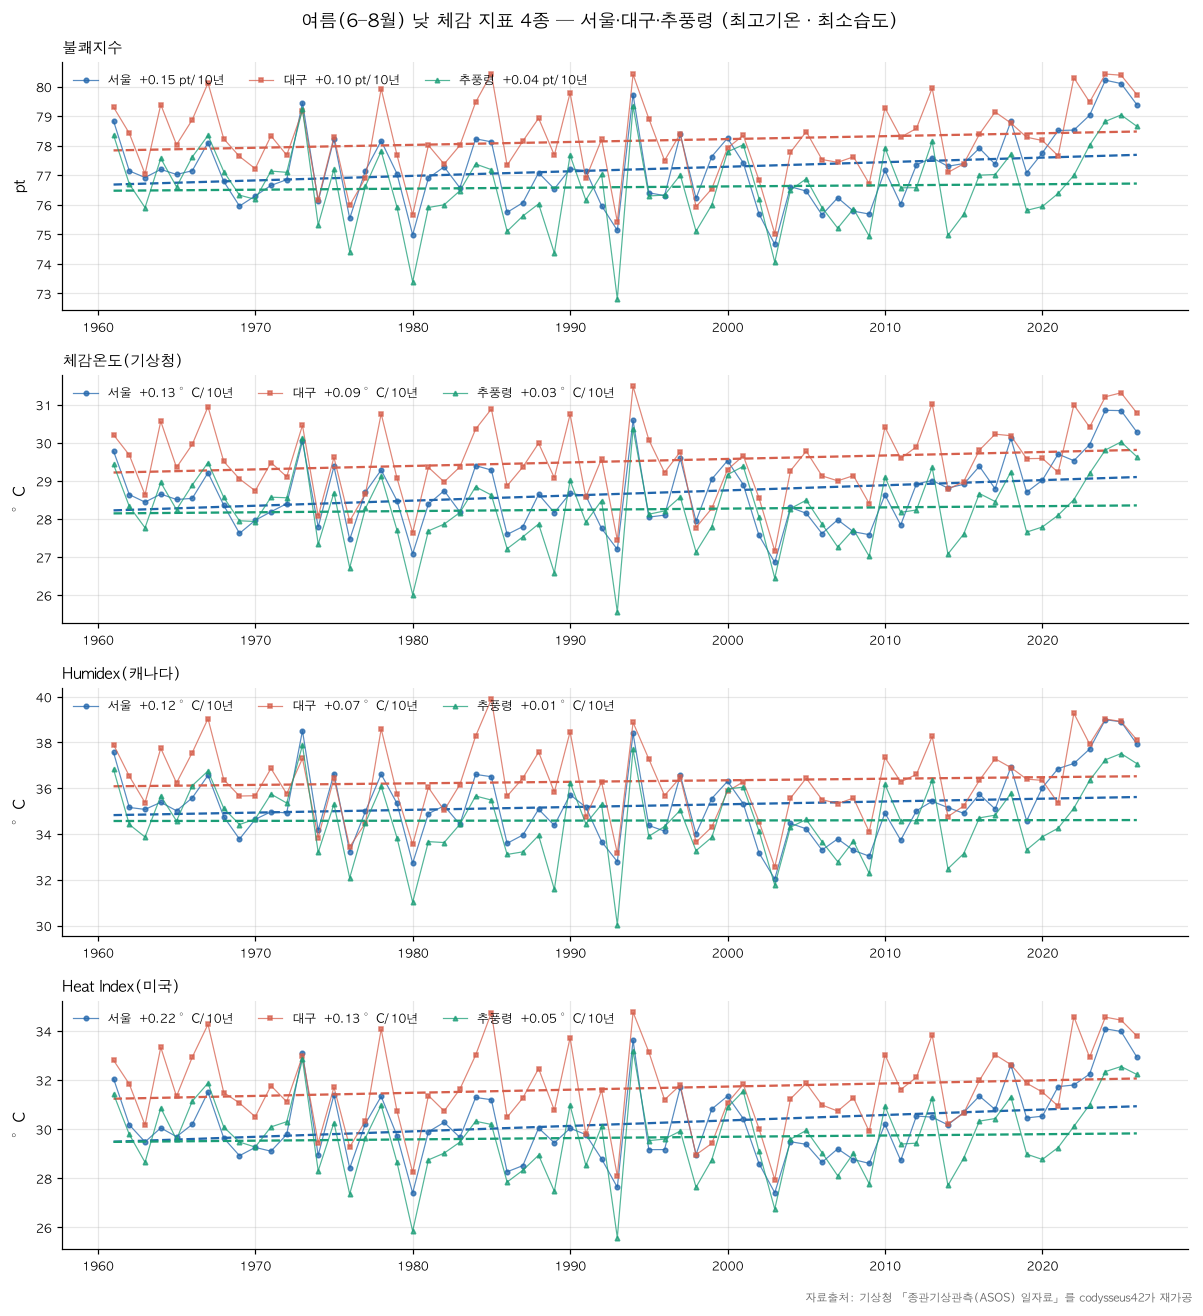

In [12]:
def wet_bulb_stull(t, rh):
    """습구온도 (Stull, 2011) — 기상청 체감온도 산출식의 입력"""
    return (t * np.arctan(0.151977 * np.sqrt(rh + 8.313659)) + np.arctan(t + rh)
            - np.arctan(rh - 1.67633) + 0.00391838 * rh ** 1.5 * np.arctan(0.023101 * rh) - 4.686035)

def apparent_temp_kma(t, rh):                                   # 기상청 여름철 체감온도 (2022 개정)
    w = wet_bulb_stull(t, rh)
    return -0.2442 + 0.55399 * w + 0.45535 * t - 0.0022 * w ** 2 + 0.00278 * w * t + 3.0

def humidex(t, rh):                                             # 캐나다 환경청
    e = 6.112 * 10 ** (7.5 * t / (237.7 + t)) * rh / 100
    return t + 5 / 9 * (e - 10)

def heat_index(t, rh):                                          # 미국 NWS (Rothfusz 회귀식 + 보정)
    T, R = t * 9 / 5 + 32, rh
    simple = 0.5 * (T + 61 + (T - 68) * 1.2 + R * 0.094)
    full = (-42.379 + 2.04901523*T + 10.14333127*R - .22475541*T*R - .00683783*T**2
            - .05481717*R**2 + .00122874*T**2*R + .00085282*T*R**2 - .00000199*T**2*R**2)
    adj1 = np.where((R < 13) & (T > 80) & (T < 112), ((13 - R) / 4) * np.sqrt(np.clip((17 - abs(T - 95)) / 17, 0, None)), 0)
    adj2 = np.where((R > 85) & (T > 80) & (T < 87), ((R - 85) / 10) * ((87 - T) / 5), 0)
    return (np.where((simple + T) / 2 >= 80, full - adj1 + adj2, simple) - 32) * 5 / 9

INDICES = {"불쾌지수": discomfort_index, "체감온도(기상청)": apparent_temp_kma,
           "Humidex(캐나다)": humidex, "Heat Index(미국)": heat_index}

# ① 지표별 습도 가중: 기온 30°C, 습도 55%에서 습도 1%p가 기온 몇 °C에 해당하는가
w = {n: float((f(30, 56) - f(30, 55)) / (f(31, 55) - f(30, 55))) for n, f in INDICES.items()}
print("습도 1%p에 해당하는 기온 변화(°C) — 기온 30°C, 습도 55% 기준")
display(pd.Series(w, name="습도 1%p ≈ 기온(°C)").round(3))
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")

# ② 지표별 원인 분해: 2020년대 낮 기준, 습도 비중
rows = []
for name in ["서울", "대구", "추풍령"]:
    d = q[q.stn_name == name]
    now_q = d[d.decade == 2020]
    for B in [1990, 2010]:
        prev_q = d[d.decade == B]
        rh_cf = shift_rh(now_q.rh_min, prev_q.rh_min)
        for iname, f in INDICES.items():
            a, b, c = (np.mean(f(x.tmax, r)) for x, r in [(prev_q, prev_q.rh_min), (now_q, now_q.rh_min), (now_q, rh_cf)])
            rows.append({"지점": name, "기준": f"{B}s", "지표": iname, "습도 비중(%)": (b - c) / (b - a) * 100})
print("지표별 습도 비중(%) — 낮 기준, 2020년대와 비교")
display(pd.DataFrame(rows).pivot_table(index=["지점", "기준"], columns="지표", values="습도 비중(%)").round(0))
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")

# ---------- Q3 그림 1: 네 가지 체감 지표, 세 지점 (낮 기준) ----------
IDX_UNIT = {"불쾌지수": "pt", "체감온도(기상청)": "°C", "Humidex(캐나다)": "°C", "Heat Index(미국)": "°C"}
for iname, f in INDICES.items():
    q[iname] = f(q.tmax, q.rh_min)
yr_idx = q.groupby([q.stn_name, q.index.year])[list(INDICES)].mean()

fig, axes = plt.subplots(len(INDICES), 1, figsize=(11, 3.0 * len(INDICES)), sharex=True)
for ax, iname in zip(axes, INDICES):
    unit = IDX_UNIT[iname]
    for name, c in STN_COLOR.items():
        y = yr_idx.loc[name, iname]
        k, b = np.polyfit(y.index, y, 1)
        ax.plot(y.index, y, marker=STN_MARK[name], ms=3, lw=0.8, color=c, alpha=0.75,
                label=f"{name}  {k*10:+.2f} {unit}/10년")
        ax.plot(y.index, k * y.index + b, "--", lw=1.5, color=c)
    ax.set_title(iname, loc="left", fontsize=10)
    ax.set_ylabel(unit)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.tick_params(labelbottom=True, labelsize=8)
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8, frameon=False, loc="upper left", ncol=3)
fig.suptitle("여름(6–8월) 낮 체감 지표 4종 — 서울·대구·추풍령 (최고기온 · 최소습도)", fontsize=12)
fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
plt.tight_layout(rect=(0, 0.01, 1, 1))
plt.savefig("imagedata/fig_q3_indices.png", bbox_inches="tight", dpi=150)
plt.show()


### Q3 소결

- 지표를 바꿔도 결론은 같다. 네 지표 모두 기온 중심이고, 66년간의 체감 악화는 기온이 이끌었다.
- 한계: 지표별 경보 기준(임계값)을 넘는 날의 비율은 비교하지 않았다.

## 추가 분석: 습도를 수증기량으로 고정한 원인 분해

상대습도는 "기온에 비해 얼마나 찼는가"라서, 수증기가 그대로여도 기온이 오르면 낮아진다.
공기중의 수증기량을 체감할수 있는 지표로 땀의 증발과 관련된 이슬점을 들 수 있다. 이슬점 20℃는 후텁지근함의 기준으로 흔히 쓰이는 수준이다.
또 최고기온과 최소 상대습도를 기준으로 수증기양을 고정하고 실제 수증기량을 계산한 뒤에 이 절대수증기양을 기준으로 불쾌지수를 계산하여 비교해 보았다.



첫 번째 표는 이슬점 20℃ 이상인 날의 비율이다.
- 관찰: 여름 평균 이슬점의 66년 추세는 세 지점 모두 0에 가깝다(서울 −0.03, 대구 −0.04, 추풍령 −0.10 °C/10년).
  그러나 이슬점 20℃ 이상인 날의 비율은 2020년대에 서울 62.4%, 대구 61.0%, 추풍령 55.4%로 세 지점 모두 관측 이래 가장 높다.
- 해석: 절대 습도는 긴 추세로는 늘지 않았지만, 2020년대에 들어 뚜렷하게 늘었다.

두 번째 표는 습도를 무엇으로 고정하느냐에 따라 낮 불쾌지수의 습도 몫이 어떻게 달라지는지다.
상대습도로 고정하면 더워지며 함께 늘어난 수증기가 기온 몫으로 들어가고, 수증기량으로 고정하면 전부 습도 몫이 된다.

관측으로 주어진 증기압은 일평균 증기압이므으로 상대습도와 포화수증기압으로 실제 수증기압 $e$(hPa)를 계산했다(`sat_vp`, `e_day`).
- 포화수증기압(Magnus 식, WMO): $e_s(T) = 6.112\exp\left(\dfrac{17.62\,T}{243.12 + T}\right)$
- 낮 시간 실제 수증기압: $e = \dfrac{RH_{min}}{100} \times e_s(T_{max})$ — 낮 불쾌지수와 시간대를 맞추려고 최고기온·최소 상대습도로 계산했다.

수증기량 고정은 ① 2020년대의 $e$를 기준 시기 평균만큼 옮기고 ② 2020년대 최고기온으로 상대습도 $RH' = e'/e_s(T_{max})\times100$로 되돌린 뒤 ③ 낮 불쾌지수를 다시 계산했다.
- 관찰: 1990년대 기준 서울의 습도 몫은 상대습도 고정 시 0.07pt(4%), 수증기량 고정 시 0.75pt(37%)다. 대구·추풍령은 1990년대 기준에서 부호가 뒤집힌다.
- 해석: 2020년대의 수증기 증가는 실제로 있지만, 상대습도를 쓰는 체감 지표에서는 기온 몫으로 들어가 잘 드러나지 않는다.

### 추가 분석 결론

- 66년 추세로는 상대습도도 절대 습도도 늘지 않았다. 추세 수준에서 "습해져서 힘들어졌다"는 근거는 없다.
- 2020년대에는 수증기가 실제로 늘었다. 이 증가는 상대습도 기반 체감 지표에 잘 드러나지 않으므로,
  "요즘 여름이 습하다"는 체감은 지표보다 이슬점으로 볼 때 부분적으로 사실이다.
한계는 다음과 같다.
1. 지표별 경보 기준(임계값)을 넘는 날의 비율은 비교하지 않았고, 2020년대는 여름 7개뿐이라
    이 도약이 추세로 이어질지는 알 수 없다.
2. 여전히 대구와 추풍령은 불쾌지수 상승폭 자체가 서울보다 작아, 수증기량 기준 비중이 커도 체감 차이는 작을 수 있다.

이슬점 20℃ 이상인 여름 날의 비율(%) — 10년 단위


decade,1960,1970,1980,1990,2000,2010,2020
stn_name,,,,,,,
대구,55.7,45.2,49.3,43.7,44.6,50.0,61.0
서울,53.6,49.9,43.6,47.4,40.9,45.9,62.4
추풍령,52.3,49.9,38.4,41.8,35.5,44.5,55.4


*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*


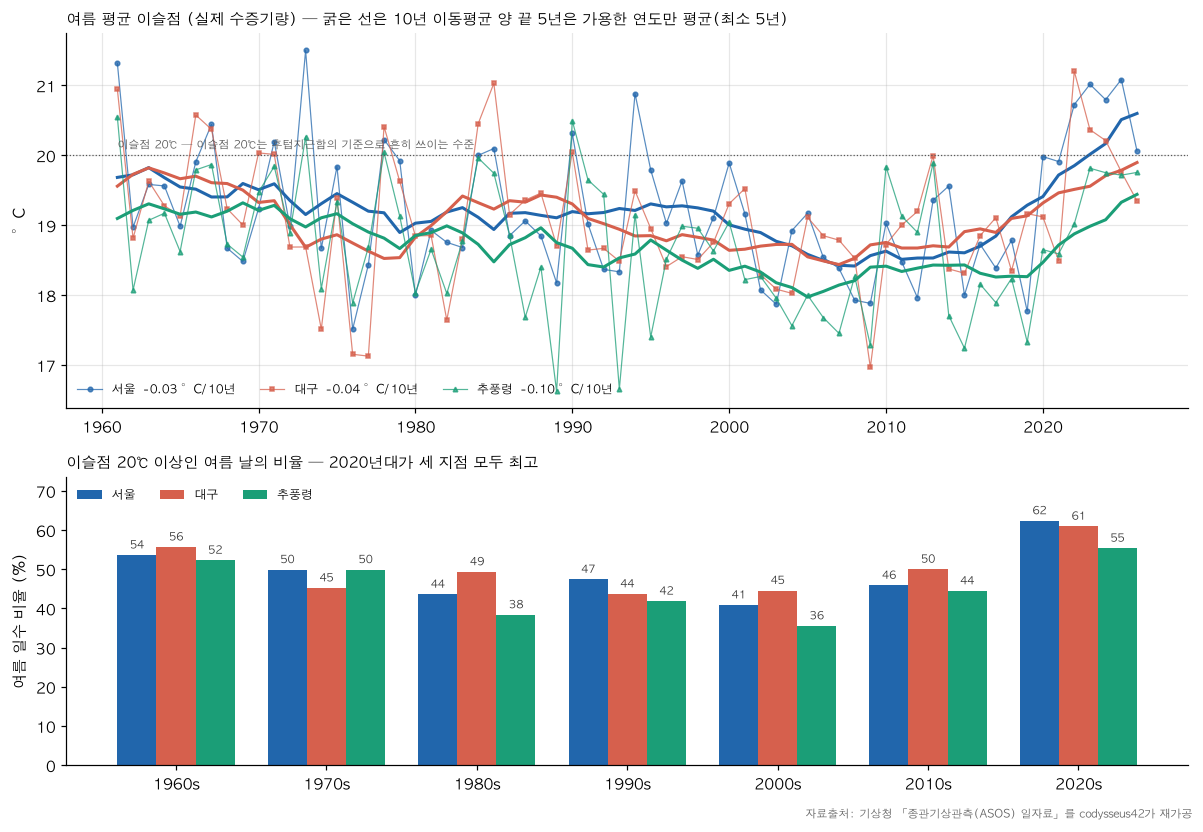

습도 고정 방식별 낮 불쾌지수의 습도 몫 — 상대습도 고정 vs 수증기량 고정


습도 몫(pt)         습도 비중(%)        
방식         상대습도 고정 수증기량 고정  상대습도 고정 수증기량 고정
지점  기준                                     
대구  1990s    -0.36    0.32   -22.07   19.67
    2010s     0.39    0.59    41.95   63.06
서울  1990s     0.07    0.75     3.51   36.61
    2010s     1.28    1.41    76.31   84.26
추풍령 1990s    -0.19    0.34   -14.10   25.54
    2010s     0.45    0.62    47.39   65.09

*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*


In [13]:
def sat_vp(t):
    """포화수증기압 (hPa, Magnus 식) — 그 기온에서 공기가 담을 수 있는 최대 수증기"""
    return 6.112 * np.exp(17.62 * t / (243.12 + t))

q["e_day"] = q.rh_min / 100 * sat_vp(q.tmax)                    # 낮 실제 수증기압 (hPa)

# ① 절대 수증기량: 이슬점 20℃ 이상인 여름 날의 비율 (10년 단위)
dew20 = (q.dew >= 20).groupby([q.stn_name, q.decade]).mean().unstack() * 100
print("이슬점 20℃ 이상인 여름 날의 비율(%) — 10년 단위")
display(dew20.round(1))
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")


# ---------- Q3 그림 2: 절대 수증기량 — 이슬점 ----------
yr_dew = q.groupby([q.stn_name, q.index.year]).dew.mean()
dew20 = (q.dew >= 20).groupby([q.stn_name, q.decade]).mean().unstack() * 100

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 7.5), gridspec_kw={"height_ratios": [1.3, 1]})
for name, c in STN_COLOR.items():
    y = yr_dew.loc[name]
    k, b = np.polyfit(y.index, y, 1)
    ax.plot(y.index, y, marker=STN_MARK[name], ms=3, lw=0.8, color=c, alpha=0.75,
            label=f"{name}  {k*10:+.2f} °C/10년")
    ax.plot(y.index, y.rolling(10, center=True, min_periods=5).mean(), lw=2, color=c)   # 10년 흐름
ax.axhline(20, color="#555", lw=0.8, ls=":")
ax.text(1961, 20.05, "이슬점 20℃ — 이슬점 20℃는 후텁지근함의 기준으로 흔히 쓰이는 수준", fontsize=7, color="#555", va="bottom")
ax.set_title("여름 평균 이슬점 (실제 수증기량) — 굵은 선은 10년 이동평균 양 끝 5년은 가용한 연도만 평균(최소 5년)", loc="left", fontsize=10)
ax.set_ylabel("°C")
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8, frameon=False, loc="lower left", ncol=3)

x = np.arange(len(dew20.columns))
wbar = 0.26
for j, (name, c) in enumerate(STN_COLOR.items()):
    v = dew20.loc[name]
    ax2.bar(x + (j - 1) * wbar, v, width=wbar, color=c, label=name)
    for xi, vi in zip(x + (j - 1) * wbar, v):
        ax2.text(xi, vi + 0.8, f"{vi:.0f}", ha="center", va="bottom", fontsize=7, color="#333")
ax2.set_xticks(x, [f"{d}s" for d in dew20.columns])
ax2.set_ylabel("여름 일수 비율 (%)")
ax2.set_ylim(0, dew20.values.max() * 1.18)
ax2.set_title("이슬점 20℃ 이상인 여름 날의 비율 — 2020년대가 세 지점 모두 최고", loc="left", fontsize=10)
ax2.legend(fontsize=8, frameon=False, loc="upper left", ncol=3)
ax2.spines[["top", "right"]].set_visible(False)
fig.text(0.99, 0.002, SOURCE, ha="right", fontsize=7, color="#666")
plt.tight_layout(rect=(0, 0.01, 1, 1))
plt.savefig("imagedata/fig_q3_dewpoint.png", bbox_inches="tight", dpi=150)
plt.show()

# ② '습도'를 무엇으로 고정하느냐에 따른 원인 분해 (낮 불쾌지수)
#    상대습도 고정: 더워지며 늘어난 수증기는 '기온 몫'으로 들어간다
#    수증기량 고정: 늘어난 수증기 전부가 '습도 몫'이 된다
rows = []
for name in ["서울", "대구", "추풍령"]:
    d = q[q.stn_name == name]
    now_q = d[d.decade == 2020]
    for B in [1990, 2010]:
        prev_q = d[d.decade == B]
        total = now_q.di_day.mean() - prev_q.di_day.mean()
        rh_fix_rh = shift_rh(now_q.rh_min, prev_q.rh_min)
        e_fix = now_q.e_day - (now_q.e_day.mean() - prev_q.e_day.mean())
        rh_fix_e = (e_fix / sat_vp(now_q.tmax) * 100).clip(0, 100)
        for how, rh_cf in [("상대습도 고정", rh_fix_rh), ("수증기량 고정", rh_fix_e)]:
            hum = now_q.di_day.mean() - discomfort_index(now_q.tmax, rh_cf).mean()
            rows.append({"지점": name, "기준": f"{B}s", "방식": how,
                         "습도 몫(pt)": hum, "습도 비중(%)": hum / total * 100})
print("습도 고정 방식별 낮 불쾌지수의 습도 몫 — 상대습도 고정 vs 수증기량 고정")
display(pd.DataFrame(rows).pivot_table(index=["지점", "기준"], columns="방식",
                                       values=["습도 몫(pt)", "습도 비중(%)"]).round(2))
print("*자료출처: 기상청 「종관기상관측(ASOS) 일자료」를 codysseus42가 재가공*")
